In [ ]:
import os
import json
import time
import numpy as np
from pathlib import Path

import torch
import torch.nn.functional as F
import timm
import onnx
import onnxruntime as ort

# ============================================================
# CONFIGURATION
# ============================================================
LOWER_DIR = Path("/content/drive/MyDrive/October_27th/model_outputs/lower_v3_base_run")
MODELS = {
    "lower_v3": {
        "ckpt": LOWER_DIR / "best_lower_cnn.pth",
        "backbone": "convnextv2_base.fcmae_ft_in22k_in1k_384",
        "img_size": 384,
        "classes": ["jeans", "jogging_bottoms", "skirts", "trousers"],
        "onnx_out": LOWER_DIR / "lower_v3.onnx",
        "thresholds": LOWER_DIR / "lower_per_class_thresholds.json",
    },
}
OPSET = 17
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# ============================================================
# HELPER FUNCTIONS
# ============================================================
def load_pytorch_model(cfg):
    """Load a trained PyTorch model from checkpoint."""
    ckpt = torch.load(cfg["ckpt"], map_location=DEVICE, weights_only=False)

    model = timm.create_model(
        cfg["backbone"],
        pretrained=False,
        num_classes=len(cfg["classes"])
    )
    model.load_state_dict(ckpt["model_state"], strict=True)
    model.to(DEVICE)
    model.eval()

    n_params = sum(p.numel() for p in model.parameters()) / 1e6
    print(f"  Loaded: {cfg['backbone']} — {n_params:.1f}M params")
    print(f"  Best F1 (train): {ckpt.get('best_f1', 'N/A')}")
    return model

def export_to_onnx(model, cfg, opset=17):
    """Export PyTorch model to ONNX with dynamic batch size."""
    img_size = cfg["img_size"]
    onnx_path = cfg["onnx_out"]

    # Dummy input
    dummy = torch.randn(1, 3, img_size, img_size, device=DEVICE)

    # Export
    print(f"  Exporting to: {onnx_path}")
    torch.onnx.export(
        model,
        dummy,
        str(onnx_path),
        opset_version=opset,
        input_names=["input"],
        output_names=["logits"],
        dynamic_axes={
            "input": {0: "batch_size"},
            "logits": {0: "batch_size"},
        },
    )

    # Validate
    onnx_model = onnx.load(str(onnx_path))
    onnx.checker.check_model(onnx_model)

    size_mb = os.path.getsize(onnx_path) / (1024 * 1024)
    print(f"  ✓ ONNX valid — {size_mb:.1f} MB")
    print(f"  Opset: {opset}")
    print(f"  Input:  input  → [batch, 3, {img_size}, {img_size}]")
    print(f"  Output: logits → [batch, {len(cfg['classes'])}]")

    return onnx_path

def validate_onnx(model, cfg):
    """Compare PyTorch vs ONNX Runtime outputs."""
    img_size = cfg["img_size"]
    onnx_path = str(cfg["onnx_out"])

    # PyTorch inference
    dummy = torch.randn(1, 3, img_size, img_size, device=DEVICE)
    with torch.no_grad():
        pt_logits = model(dummy).cpu().numpy()

    # ONNX Runtime inference
    providers = ["CUDAExecutionProvider", "CPUExecutionProvider"]
    session = ort.InferenceSession(onnx_path, providers=providers)
    ort_logits = session.run(
        ["logits"],
        {"input": dummy.cpu().numpy()}
    )[0]

    # Compare
    max_diff = np.abs(pt_logits - ort_logits).max()
    mean_diff = np.abs(pt_logits - ort_logits).mean()
    pt_pred = pt_logits.argmax(1)
    ort_pred = ort_logits.argmax(1)
    preds_match = (pt_pred == ort_pred).all()

    print(f"  Max  abs diff: {max_diff:.8f}")
    print(f"  Mean abs diff: {mean_diff:.8f}")
    print(f"  Predictions match: {preds_match}")

    if max_diff < 1e-4:
        print(f"  ✓ Outputs match within tolerance")
    else:
        print(f"  ⚠ Outputs differ beyond 1e-4 — check model")

    return session

def benchmark_onnx(cfg, n_warmup=10, n_runs=50):
    """Benchmark ONNX Runtime latency."""
    img_size = cfg["img_size"]
    onnx_path = str(cfg["onnx_out"])

    providers = ["CUDAExecutionProvider", "CPUExecutionProvider"]
    session = ort.InferenceSession(onnx_path, providers=providers)

    active = session.get_providers()
    print(f"  Active providers: {active}")

    dummy_np = np.random.randn(1, 3, img_size, img_size).astype(np.float32)

    # Warmup
    for _ in range(n_warmup):
        session.run(["logits"], {"input": dummy_np})

    # Benchmark
    times = []
    for _ in range(n_runs):
        t0 = time.perf_counter()
        session.run(["logits"], {"input": dummy_np})
        times.append((time.perf_counter() - t0) * 1000)

    times = np.array(times)
    print(f"  Latency (ms): mean={times.mean():.1f}, median={np.median(times):.1f}, "
          f"p95={np.percentile(times, 95):.1f}, min={times.min():.1f}, max={times.max():.1f}")
    print(f"  Throughput: ~{1000/times.mean():.0f} img/s (batch=1)")

    return times

# ============================================================
# MAIN EXECUTION
# ============================================================
print("=" * 60)
print("  LOWER V3 — ConvNeXt-V2-Base (384px)")
print("=" * 60)

cfg = MODELS["lower_v3"]
lower_model = load_pytorch_model(cfg)
print()
export_to_onnx(lower_model, cfg, opset=OPSET)
print()
validate_onnx(lower_model, cfg)
print()
benckmark_onnx(cfg)

# ============================================================
# METADATA GENERATION
# ============================================================
for name, cfg_meta in MODELS.items(): # Renamed cfg to cfg_meta to avoid conflict with main cfg
    # Load thresholds if available
    thresholds = {}
    if cfg_meta["thresholds"].exists():
        with open(cfg_meta["thresholds"]) as f:
            tdata = json.load(f)
        thresholds = tdata.get("thresholds", {})

    meta = {
        "model_name": name,
        "backbone": cfg_meta["backbone"],
        "onnx_file": cfg_meta["onnx_out"].name,
        "opset": OPSET,
        "input_name": "input",
        "output_name": "logits",
        "input_shape": [1, 3, cfg_meta["img_size"], cfg_meta["img_size"]],
        "dynamic_batch": True,
        "classes": cfg_meta["classes"],
        "num_classes": len(cfg_meta["classes"]),
        "preprocessing": {
            "resize": [cfg_meta["img_size"], cfg_meta["img_size"]],
            "normalize_mean": [0.485, 0.456, 0.406],
            "normalize_std": [0.229, 0.224, 0.225],
            "channel_order": "RGB",
            "tensor_format": "NCHW",
            "dtype": "float32",
        },
        "thresholds": thresholds,
    }

    meta_path = cfg_meta["onnx_out"].with_suffix(".json")
    with open(meta_path, "w") as f:
        json.dump(meta, f, indent=2)

    print(f"✓ {name}: {meta_path}")
    print(f"  Classes: {cfg_meta['classes']}")
    print(f"  Thresholds: {thresholds}")
    print()

print("\n" + "=" * 60)
print("  EXPORT SUMMARY")
print("=" * 60)

for name, cfg_summary in MODELS.items(): # Renamed cfg to cfg_summary
    onnx_path = cfg_summary["onnx_out"]
    meta_path = onnx_path.with_suffix(".json")
    size_mb = os.path.getsize(onnx_path) / (1024 * 1024)

    print(f"\n  {name}:")
    print(f"    ONNX:      {onnx_path} ({size_mb:.1f} MB)")
    print(f"    Metadata:  {meta_path}")
    print(f"    Backbone:  {cfg_summary['backbone']}")
    print(f"    Input:     [batch, 3, {cfg_summary['img_size']}, {cfg_summary['img_size']}]")
    print(f"    Classes:   {cfg_summary['classes']}")

print(f"\n{'='*60}")
print("  All exports complete!")
print("="*60)

In [ ]:
import os, time, json, random, warnings
from pathlib import Path
from collections import defaultdict, Counter
import numpy as np
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn.functional as F
from torch import nn
from torch.utils.data import Dataset, DataLoader, Sampler
import timm

import albumentations as A
from albumentations.pytorch import ToTensorV2

from transformers import CLIPModel, CLIPProcessor
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

warnings.filterwarnings("ignore")


# ============================================================
# CONFIG
# ============================================================
ROOT = "/content/drive/Shareddrives/Garment Type/Complete_dataset"
OUTDIR = Path("/content/drive/MyDrive/October_27th/model_outputs/lower_v3_base_run")
OUTDIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

# ============================================================
# CHANGES FROM V2-TINY LOWER SCRIPT
# ============================================================
# 1. Backbone: convnextv2_tiny → convnextv2_base (89M vs 28M)
# 2. Resolution: 448 → 384 (native for Base-384 variant)
# 3. Batch size: 48 → 16 (larger model, AMP keeps VRAM manageable)
# 4. Backbone LR: 1e-5 → 5e-6 (gentler — bigger model, richer features)
# 5. Head LR: 1.5e-4 → 1e-4
# 6. Val batch: 64 → 24 (VRAM constraint)
# 7. Head epochs: 8 → 10 (more warmup for bigger head)
# ============================================================

# IMAGE SIZE — native resolution for Base-384 variant
IMG_SIZE = 384

# BACKBONE — ConvNeXt-V2 Base with FCMAE + IN-22k pretraining
BACKBONE = "convnextv2_base.fcmae_ft_in22k_in1k_384"

# TRAINING PARAMS
BATCH = 16              # reduced for 89M model at 384px
EPOCHS = 100
HEAD_EPOCHS = 10        # more warmup for bigger classifier head

LR_HEAD = 5e-4          # Stage 1 head-only LR
BACKBONE_LR = 5e-6      # Stage 2 backbone LR — gentler for Base
HEAD_LR = 1e-4           # Stage 2 head LR
WEIGHT_DECAY = 1e-2

PATIENCE = 15
WARMUP_EPOCHS = 5
NUM_WORKERS = 2

MIN_SAMPLES_FOR_BALANCED = 12

# LOSS SETTINGS
LABEL_SMOOTH = 0.05
FOCAL_GAMMA = 2.0

# MIXUP
MIXUP_ALPHA = 0.2
MIXUP_PROB = 0.3         # conservative — let Base learn clean features first

# VAL SPLIT
VAL_RATIO = 0.16

torch.backends.cudnn.benchmark = True
torch.set_float32_matmul_precision("high")

LOWER_CLASSES = ["jeans", "jogging_bottoms", "skirts", "trousers"]

MINORITY_CLASSES = {"skirts"}
MEDIUM_CLASSES = {"jeans"}   # jeans is mid-sized (702 vs 1847 trousers)


# ============================================================
# FOCAL LOSS + LABEL SMOOTHING
# ============================================================
def focal_loss_with_ls(logits, targets, gamma=2.0, smooth=0.05, weight=None):
    num_classes = logits.shape[1]
    one_hot = F.one_hot(targets, num_classes).float().to(logits.device)
    one_hot = one_hot * (1 - smooth) + smooth / num_classes

    log_probs = F.log_softmax(logits, dim=1)
    probs = torch.exp(log_probs)

    focal_factor = (1 - probs) ** gamma
    loss = -one_hot * focal_factor * log_probs
    loss = loss.sum(dim=1)

    if weight is not None:
        loss = loss * weight[targets]

    return loss.mean()


def focal_loss_mixup(logits, targets_a, targets_b, lam, gamma=2.0, smooth=0.05, weight=None):
    loss_a = focal_loss_with_ls(logits, targets_a, gamma, smooth, weight)
    loss_b = focal_loss_with_ls(logits, targets_b, gamma, smooth, weight)
    return lam * loss_a + (1 - lam) * loss_b


# ============================================================
# MIXUP
# ============================================================
def mixup_data(x, y, alpha=0.2):
    lam = np.random.beta(alpha, alpha) if alpha > 0 else 1.0
    lam = max(lam, 1 - lam)

    batch_size = x.size(0)
    index = torch.randperm(batch_size, device=x.device)

    mixed_x = lam * x + (1 - lam) * x[index]
    y_a, y_b = y, y[index]

    return mixed_x, y_a, y_b, lam


# ============================================================
# UTILITIES
# ============================================================
def collect_samples(root, allowed_classes):
    root = Path(root)
    samples = []

    for dataset_dir in root.iterdir():
        if not dataset_dir.is_dir():
            continue
        for cls_dir in dataset_dir.iterdir():
            if not cls_dir.is_dir():
                continue
            cls_name = cls_dir.name.lower()
            if cls_name not in allowed_classes:
                continue
            for img_path in cls_dir.iterdir():
                if img_path.is_file():
                    samples.append((str(img_path), cls_name))

    return samples


# ============================================================
# AUGMENTATIONS
# ============================================================
def build_aug(img_size, is_train=True):
    h = w = img_size

    if not is_train:
        return A.Compose([
            A.Resize(h, w),
            A.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
            ToTensorV2()
        ])

    return A.Compose([
        A.RandomResizedCrop(
            size=(h, w),
            scale=(0.75, 1.0),
            ratio=(0.75, 1.3),
            p=1.0
        ),
        A.HorizontalFlip(p=0.5),
        A.ShiftScaleRotate(
            shift_limit=0.04,
            scale_limit=0.08,
            rotate_limit=8,
            p=0.6
        ),
        A.ColorJitter(0.2, 0.2, 0.2, 0.05, p=0.6),
        A.GaussianBlur(3, p=0.2),
        A.CoarseDropout(
            max_holes=4,
            max_height=int(h * 0.10),
            max_width=int(w * 0.10),
            p=0.3
        ),
        A.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
        ToTensorV2()
    ])


def build_strong_aug(img_size):
    h = w = img_size
    return A.Compose([
        A.RandomResizedCrop(
            size=(h, w),
            scale=(0.60, 1.0),
            ratio=(0.70, 1.4),
            p=1.0
        ),
        A.HorizontalFlip(p=0.5),
        A.ShiftScaleRotate(
            shift_limit=0.06,
            scale_limit=0.12,
            rotate_limit=12,
            p=0.8
        ),
        A.ColorJitter(0.25, 0.25, 0.25, 0.08, p=0.8),
        A.GaussianBlur(blur_limit=3, p=0.3),
        A.CoarseDropout(
            max_holes=6,
            max_height=int(h * 0.12),
            max_width=int(w * 0.12),
            p=0.4
        ),
        A.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
        ToTensorV2()
    ])


# ============================================================
# DATASET
# ============================================================
class ImgDataset(Dataset):
    def __init__(self, samples, cls2idx, img_size, aug=True):
        self.samples = samples
        self.cls2idx = cls2idx
        self.img_size = img_size
        self.aug = aug

        self.base_aug = build_aug(img_size, is_train=aug)
        self.strong_aug = build_strong_aug(img_size)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, i):
        p, c = self.samples[i]

        try:
            img = np.array(Image.open(p).convert("RGB"))
        except:
            img = np.zeros((self.img_size, self.img_size, 3), dtype=np.uint8)

        if self.aug and c in MINORITY_CLASSES:
            data = self.strong_aug(image=img)
        elif self.aug and c in MEDIUM_CLASSES:
            if random.random() < 0.5:
                data = self.strong_aug(image=img)
            else:
                data = self.base_aug(image=img)
        else:
            data = self.base_aug(image=img)

        return data["image"], self.cls2idx[c], p


# ============================================================
# BALANCED SAMPLER
# ============================================================
class BalancedBatchSampler(Sampler):
    def __init__(self, labels, n_cls, n_per):
        self.labels = labels
        self.n_cls = n_cls
        self.n_per = n_per

        self.lab2idx = defaultdict(list)
        for i, l in enumerate(labels):
            self.lab2idx[l].append(i)

        for l in self.lab2idx:
            random.shuffle(self.lab2idx[l])

        self.classes = list(self.lab2idx.keys())
        self.used = {c: 0 for c in self.classes}
        self.num_batches = sum(len(v) for v in self.lab2idx.values()) // (n_cls * n_per)

    def __iter__(self):
        for _ in range(self.num_batches):
            chosen = random.sample(self.classes, self.n_cls)
            batch = []
            for c in chosen:
                st = self.used[c]
                en = st + self.n_per
                if en > len(self.lab2idx[c]):
                    random.shuffle(self.lab2idx[c])
                    st = 0; en = self.n_per
                batch.extend(self.lab2idx[c][st:en])
                self.used[c] = en
            yield batch

    def __len__(self):
        return self.num_batches


# ============================================================
# PROBE MODEL (CLIP → lower classes)
# ============================================================
class ProbeNet(nn.Module):
    def __init__(self, in_dim, hid, ncls):
        super().__init__()
        self.norm = nn.LayerNorm(in_dim)
        self.fc1 = nn.Linear(in_dim, hid)
        self.fc2 = nn.Linear(hid, hid)
        self.drop = nn.Dropout(0.4)
        self.out = nn.Linear(hid, ncls)
        self.act = nn.GELU()

    def forward(self, x):
        x = self.norm(x)
        x = self.act(self.fc1(x))
        x = self.drop(x)
        x = self.act(self.fc2(x))
        x = self.drop(x)
        return self.out(x)


# ============================================================
# LOAD DATA
# ============================================================
print("Scanning:", ROOT)

samples = collect_samples(ROOT, set(LOWER_CLASSES))

class_counts = Counter(c for _, c in samples)
print("\n=== TOTAL IMAGE COUNT PER CLASS ===")
for cls, cnt in class_counts.most_common():
    print(f"  {cls:20s} : {cnt}")
print(f"  {'TOTAL':20s} : {len(samples)}")

# Train/Val split — 16% val, stratified
by_class = defaultdict(list)
for p, c in samples:
    by_class[c].append((p, c))

train_samples = []
val_samples = []
rng = random.Random(SEED)

for c, arr in by_class.items():
    arr = list(arr)
    rng.shuffle(arr)
    nval = max(2, int(len(arr) * VAL_RATIO))
    val_samples += arr[:nval]
    train_samples += arr[nval:]

print(f"\nTrain: {len(train_samples)}  Val: {len(val_samples)}")

# Save validation split for threshold calibration later
val_split_info = [{"path": p, "label": c} for p, c in val_samples]
val_split_path = OUTDIR / "val_split.json"
with open(val_split_path, "w") as f:
    json.dump(val_split_info, f, indent=2)
print(f"Val split saved to: {val_split_path}  ({len(val_samples)} samples)")


# ============================================================
# PREPARE CLIP EMBEDDINGS (cached to disk)
# ============================================================
def prepare_clip_embeddings(all_samples, cache_path):
    """Pre-compute CLIP embeddings for all samples, cache to disk."""
    if cache_path.exists():
        print(f"Loading cached CLIP embeddings from {cache_path}")
        data = np.load(cache_path, allow_pickle=True)
        return dict(data)

    print("Preparing CLIP embeddings...")
    clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(DEVICE).eval()
    clip_proc = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32", use_fast=True)

    path2emb = {}
    batch_paths = []
    batch_imgs = []
    batch_size = 32

    with torch.no_grad():
        for i, (p, _) in enumerate(tqdm(all_samples, desc="Computing CLIP embeddings")):
            try:
                img = Image.open(p).convert("RGB")
            except:
                continue

            batch_paths.append(p)
            batch_imgs.append(img)

            if len(batch_imgs) >= batch_size or i == len(all_samples) - 1:
                inputs = clip_proc(images=batch_imgs, return_tensors="pt").to(DEVICE)
                embs = clip_model.get_image_features(**inputs).pooler_output # FIX: Access pooler_output
                embs = embs / embs.norm(dim=-1, keepdim=True)
                embs = embs.cpu().numpy()

                for bp, emb in zip(batch_paths, embs):
                    path2emb[bp] = emb

                batch_paths = []
                batch_imgs = []

    # Save cache
    np.savez(cache_path, **path2emb)
    print(f"CLIP cache saved. ({len(path2emb)} embeddings)")

    del clip_model, clip_proc
    torch.cuda.empty_cache()

    return path2emb


clip_cache_path = OUTDIR / "clip_embeddings.npz"
all_samples_combined = train_samples + val_samples
clip_embeddings = prepare_clip_embeddings(all_samples_combined, clip_cache_path)


# ============================================================
# TRAIN CNN
# ============================================================
def train_lower():
    cls2idx = {c: i for i, c in enumerate(sorted(LOWER_CLASSES))}
    print(f"\nClasses: {cls2idx}")

    tr = train_samples
    vl = val_samples

    cnt = Counter([c for _, c in tr])
    print("Train counts:", dict(cnt))

    labels = [c for _, c in tr]

    # --- Balanced sampler ---
    if all(cnt[c] >= MIN_SAMPLES_FOR_BALANCED for c in cnt):
        ncls = min(len(LOWER_CLASSES), 4)
        nper = max(2, BATCH // ncls)
        sampler = BalancedBatchSampler(labels, ncls, nper)
        tr_ds = ImgDataset(tr, cls2idx, IMG_SIZE, aug=True)
        tr_loader = DataLoader(
            tr_ds,
            batch_sampler=sampler,
            num_workers=NUM_WORKERS,
            pin_memory=True,
            persistent_workers=True
        )
    else:
        tr_ds = ImgDataset(tr, cls2idx, IMG_SIZE, aug=True)
        weights = [1 / (cnt[c] + 1e-6) for c in labels]
        sampler = torch.utils.data.WeightedRandomSampler(weights, len(weights))
        tr_loader = DataLoader(
            tr_ds,
            batch_size=BATCH,
            sampler=sampler,
            num_workers=NUM_WORKERS,
            pin_memory=True,
            persistent_workers=True
        )

    vl_ds = ImgDataset(vl, cls2idx, IMG_SIZE, aug=False)
    vl_loader = DataLoader(vl_ds, batch_size=24, shuffle=False, num_workers=2)

    # ============================================================
    # CLASS WEIGHTS
    # ============================================================
    class_w = torch.ones(len(cls2idx), device=DEVICE)

    for cls, idx in cls2idx.items():
        n = cnt.get(cls, 0)
        if n > 0:
            class_w[idx] = (1 - 0.9999) / (1 - (0.9999 ** n))
        else:
            class_w[idx] = 1.0

    class_w = class_w / class_w.mean()

    # Boost skirts (minority + confusable)
    boost = {
        "skirts": 1.8,
        "jogging_bottoms": 1.2,
    }

    for cls, factor in boost.items():
        if cls in cls2idx:
            class_w[cls2idx[cls]] *= factor

    class_w = class_w / class_w.mean()

    print(f"\nClass weights:")
    for cls in sorted(cls2idx.keys()):
        print(f"  {cls:20s}: {class_w[cls2idx[cls]]:.4f}")

    # ============================================================
    # CREATE MODEL — ConvNeXt V2 Base
    # ============================================================
    print(f"\nBackbone: {BACKBONE}")
    model = timm.create_model(BACKBONE, pretrained=True, num_classes=len(cls2idx)).to(DEVICE)

    total_params = sum(p.numel() for p in model.parameters())
    print(f"Total parameters: {total_params / 1e6:.1f}M")

    scaler = torch.amp.GradScaler("cuda")

    # ============================================================
    # STAGE 1: TRAIN CLASSIFIER HEAD ONLY
    # ============================================================
    print(f"\n--- Stage 1: Head-only training ({HEAD_EPOCHS} epochs) ---")

    for p in model.parameters():
        p.requires_grad = False
    for p in model.get_classifier().parameters():
        p.requires_grad = True

    opt = torch.optim.AdamW(
        model.get_classifier().parameters(),
        lr=LR_HEAD,
        weight_decay=WEIGHT_DECAY
    )

    for ep in range(1, HEAD_EPOCHS + 1):
        model.train()
        losses = []

        for xb, yb, _ in tr_loader:
            xb = xb.to(DEVICE, non_blocking=True)
            yb = yb.to(DEVICE, non_blocking=True)

            opt.zero_grad(set_to_none=True)

            with torch.amp.autocast("cuda"):
                out = model(xb)
                loss = focal_loss_with_ls(out, yb, gamma=FOCAL_GAMMA, smooth=LABEL_SMOOTH, weight=class_w)

            scaler.scale(loss).backward()
            scaler.step(opt)
            scaler.update()

            losses.append(loss.item())

        print(f"  [head] ep{ep}/{HEAD_EPOCHS}  loss={np.mean(losses):.4f}")

    # ============================================================
    # STAGE 2: FULL FINE-TUNING (ReduceLROnPlateau + MixUp)
    # ============================================================
    print(f"\n--- Stage 2: Full fine-tuning ({EPOCHS} epochs, MixUp α={MIXUP_ALPHA}) ---")

    for p in model.parameters():
        p.requires_grad = True

    head_params = list(model.get_classifier().parameters())
    head_ids = set(map(id, head_params))
    backbone_params = [p for p in model.parameters() if id(p) not in head_ids]

    opt = torch.optim.AdamW([
        {"params": backbone_params, "lr": BACKBONE_LR},
        {"params": head_params, "lr": HEAD_LR},
    ], weight_decay=WEIGHT_DECAY)

    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt,
        mode="max",          # watching val F1
        patience=6,          # wait 6 epochs before reducing
        factor=0.5,          # halve LR on plateau
        min_lr=1e-7,
    )

    # Store initial LRs for warmup
    initial_lrs = [g["lr"] for g in opt.param_groups]

    best_f1 = -1
    patience_counter = 0

    # ============================================================
    # CRASH-SAFE RESUMABLE CHECKPOINT (helpers + resume)
    # ============================================================
    import shutil as _shutil
    LAST_CKPT_NAME = "best_lower_cnn_last.pth"

    def _atomic_save(obj, final_path):
        tmp = str(final_path) + ".tmp"
        torch.save(obj, tmp)
        os.replace(tmp, final_path)

    def _save_last(state, name, out_dir):
        local = os.path.join("/content", name)
        _atomic_save(state, local)
        drive = os.path.join(str(out_dir), name)
        if drive.endswith(".pt"):     prev = drive[:-3] + "_prev.pt"
        elif drive.endswith(".pth"):  prev = drive[:-4] + "_prev.pth"
        else:                         prev = drive + "_prev"
        try:
            if os.path.exists(drive):
                try: _shutil.copy2(drive, prev)
                except Exception: pass
            tmp = drive + ".tmp"
            _shutil.copy2(local, tmp)
            os.replace(tmp, drive)
        except Exception as e:
            print(f"  [last-ckpt] Drive copy failed (local copy still safe): {e}")

    def _try_load_last(name, out_dir):
        if name.endswith(".pt"):     prev = name[:-3] + "_prev.pt"
        elif name.endswith(".pth"):  prev = name[:-4] + "_prev.pth"
        else:                        prev = name + "_prev"
        for p in [os.path.join("/content", name),
                  os.path.join(str(out_dir), name),
                  os.path.join(str(out_dir), prev)]:
            if not os.path.exists(p): continue
            try:
                ck = torch.load(p, map_location="cpu", weights_only=False)
                _ = ck["epoch"]; _ = ck["model_state"]; _ = ck["optimizer"]
                print(f"  [resume] found checkpoint at {p} (epoch {ck['epoch']})")
                return ck
            except Exception as e:
                print(f"  [resume] corrupt ckpt at {p}: {e}")
        print("  [resume] no resume checkpoint — starting fresh.")
        return None

    # --- Try to resume previous training run ---
    start_ep = 1
    _resume = _try_load_last(LAST_CKPT_NAME, OUTDIR)
    if _resume is not None:
        model.load_state_dict(_resume["model_state"])
        opt.load_state_dict(_resume["optimizer"])
        try: sched.load_state_dict(_resume["scheduler"])
        except Exception as _e: print(f"  [resume] scheduler restore skipped: {_e}")
        try: scaler.load_state_dict(_resume["scaler"])
        except Exception as _e: print(f"  [resume] scaler restore skipped: {_e}")
        start_ep         = _resume["epoch"] + 1
        best_f1          = _resume.get("best_f1", best_f1)
        patience_counter = _resume.get("patience_counter", 0)
        if "rng_torch"  in _resume:
            try: torch.set_rng_state(_resume["rng_torch"])
            except Exception: pass
        if "rng_numpy"  in _resume:
            try: np.random.set_state(_resume["rng_numpy"])
            except Exception: pass
        if "rng_python" in _resume:
            try: random.setstate(_resume["rng_python"])
            except Exception: pass
        if "rng_cuda"   in _resume and torch.cuda.is_available() and _resume["rng_cuda"] is not None:
            try: torch.cuda.set_rng_state_all(_resume["rng_cuda"])
            except Exception: pass
        print(f"  [resume] best_f1={best_f1:.4f}, patience={patience_counter}, next_ep={start_ep}")
        del _resume

    for ep in range(start_ep, EPOCHS + 1):
        model.train()
        losses = []
        n_mixup = 0

        for xb, yb, _ in tr_loader:
            xb = xb.to(DEVICE, non_blocking=True)
            yb = yb.to(DEVICE, non_blocking=True)

            opt.zero_grad(set_to_none=True)

            with torch.amp.autocast("cuda"):
                if random.random() < MIXUP_PROB:
                    xb_mixed, ya, yb_mix, lam = mixup_data(xb, yb, alpha=MIXUP_ALPHA)
                    out = model(xb_mixed)
                    loss = focal_loss_mixup(
                        out, ya, yb_mix, lam,
                        gamma=FOCAL_GAMMA, smooth=LABEL_SMOOTH, weight=class_w
                    )
                    n_mixup += 1
                else:
                    out = model(xb)
                    loss = focal_loss_with_ls(
                        out, yb, gamma=FOCAL_GAMMA, smooth=LABEL_SMOOTH, weight=class_w
                    )

            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(opt)
            scaler.update()

            losses.append(loss.item())

        # LR schedule: warmup then plateau-based (after validation below)
        if ep <= WARMUP_EPOCHS:
            scale = ep / float(WARMUP_EPOCHS)
            for g, init_lr in zip(opt.param_groups, initial_lrs):
                g["lr"] = init_lr * scale

        # ============================================================
        # VALIDATION
        # ============================================================
        model.eval()
        y_true = []
        y_pred = []
        all_logits = []

        with torch.no_grad():
            for xb, yb, _ in vl_loader:
                xb = xb.to(DEVICE, non_blocking=True)

                with torch.amp.autocast("cuda"):
                    logits = model(xb)

                preds = logits.argmax(1).cpu().numpy()
                y_pred += preds.tolist()
                y_true += yb.numpy().tolist()
                all_logits.append(logits.cpu())

        f1 = f1_score(y_true, y_pred, average="macro")
        acc = accuracy_score(y_true, y_pred)
        cur_lr = opt.param_groups[0]["lr"]

        # Step plateau scheduler after warmup
        if ep > WARMUP_EPOCHS:
            old_lr = opt.param_groups[0]["lr"]
            sched.step(f1)
            new_lr = opt.param_groups[0]["lr"]
            if new_lr < old_lr:
                print(f"  ↓ LR reduced: {old_lr:.2e} → {new_lr:.2e}")
                cur_lr = new_lr

        print(f"  [full] ep{ep}/{EPOCHS}  loss={np.mean(losses):.4f}  "
              f"f1={f1:.4f}  acc={acc:.4f}  lr={cur_lr:.2e}  "
              f"mixup={n_mixup}")

        if f1 > best_f1:
            best_f1 = f1
            patience_counter = 0

            torch.save({
                "model_state": model.state_dict(),
                "classes": sorted(cls2idx.keys()),
                "branch": "lower",
                "backbone": BACKBONE,
                "img_size": IMG_SIZE,
                "best_f1": best_f1,
            }, OUTDIR / "best_lower_cnn.pth")

            # Save validation logits for threshold calibration
            all_logits_cat = torch.cat(all_logits, dim=0)
            all_probs = torch.softmax(all_logits_cat, dim=1).numpy()
            np.savez(
                OUTDIR / "val_predictions.npz",
                y_true=np.array(y_true),
                y_pred=np.array(y_pred),
                probs=all_probs,
                classes=sorted(cls2idx.keys())
            )

            print(f"  ✓ Saved BEST CNN (f1={best_f1:.4f}) + val predictions")
        else:
            patience_counter += 1

        # --- Save resumable "last" checkpoint every epoch ---
        _last_state = {
            "epoch": ep,
            "model_state": model.state_dict(),
            "optimizer": opt.state_dict(),
            "scheduler": sched.state_dict(),
            "scaler": scaler.state_dict(),
            "best_f1": best_f1,
            "patience_counter": patience_counter,
            "rng_torch": torch.get_rng_state(),
            "rng_cuda": torch.cuda.get_rng_state_all() if torch.cuda.is_available() else None,
            "rng_numpy": np.random.get_state(),
            "rng_python": random.getstate(),
        }
        _save_last(_last_state, LAST_CKPT_NAME, OUTDIR)
        del _last_state

        if patience_counter >= PATIENCE:
            print(f"  Early stopping at ep{ep} (patience={PATIENCE})")
            break

    # ============================================================
    # FINAL CNN REPORT
    # ============================================================
    print(f"\n{'='*60}")
    print(f"  CNN TRAINING COMPLETE — Best F1: {best_f1:.4f}")
    print(f"{'='*60}")

    rep = classification_report(y_true, y_pred, target_names=sorted(cls2idx.keys()), digits=4)
    print(rep)

    (OUTDIR / "lower_cnn_report.txt").write_text(rep)
    np.save(OUTDIR / "lower_cnn_cm.npy", confusion_matrix(y_true, y_pred))

    return best_f1, cls2idx


# ============================================================
# TRAIN PROBE (CLIP → lower classes)
# ============================================================
def train_probe(cls2idx):
    print(f"\n{'='*60}")
    print(f"  TRAINING PROBE (CLIP → lower classes)")
    print(f"{'='*60}")

    ncls = len(cls2idx)

    # Build probe training data from cached CLIP embeddings
    tr_embs, tr_labels = [], []
    for p, c in train_samples:
        if p in clip_embeddings:
            tr_embs.append(clip_embeddings[p])
            tr_labels.append(cls2idx[c])

    vl_embs, vl_labels = [], []
    for p, c in val_samples:
        if p in clip_embeddings:
            vl_embs.append(clip_embeddings[p])
            vl_labels.append(cls2idx[c])

    tr_embs = torch.tensor(np.array(tr_embs), dtype=torch.float32)
    tr_labels = torch.tensor(tr_labels, dtype=torch.long)
    vl_embs = torch.tensor(np.array(vl_embs), dtype=torch.float32)
    vl_labels = torch.tensor(vl_labels, dtype=torch.long)

    print(f"  Probe train: {len(tr_embs)}  Probe val: {len(vl_embs)}")

    # Class weights for probe (same approach)
    cnt = Counter(tr_labels.numpy().tolist())
    probe_w = torch.ones(ncls, device=DEVICE)
    for idx in range(ncls):
        n = cnt.get(idx, 0)
        if n > 0:
            probe_w[idx] = (1 - 0.9999) / (1 - (0.9999 ** n))
        else:
            probe_w[idx] = 1.0

    probe_w = probe_w / probe_w.mean()

    # Skirts boost for probe too
    skirts_idx = cls2idx.get("skirts", -1)
    if skirts_idx >= 0:
        probe_w[skirts_idx] *= 1.5
        probe_w = probe_w / probe_w.mean()

    probe = ProbeNet(512, 768, ncls).to(DEVICE)
    opt = torch.optim.AdamW(probe.parameters(), lr=3e-4, weight_decay=1e-3)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=100)

    best_probe_f1 = -1
    probe_batch = 128

    for ep in range(100):
        probe.train()
        perm = torch.randperm(len(tr_embs))
        losses = []

        for i in range(0, len(tr_embs), probe_batch):
            idx = perm[i:i+probe_batch]
            xb = tr_embs[idx].to(DEVICE)
            yb = tr_labels[idx].to(DEVICE)

            opt.zero_grad()
            logits = probe(xb)
            loss = focal_loss_with_ls(logits, yb, gamma=FOCAL_GAMMA, smooth=0.05, weight=probe_w)
            loss.backward()
            opt.step()
            losses.append(loss.item())

        sched.step()

        # Validate
        probe.eval()
        with torch.no_grad():
            vl_logits = probe(vl_embs.to(DEVICE))
            vl_preds = vl_logits.argmax(1).cpu().numpy()
            vl_true = vl_labels.numpy()

        pf1 = f1_score(vl_true, vl_preds, average="macro")

        if pf1 > best_probe_f1:
            best_probe_f1 = pf1
            torch.save({
                "probe": probe.state_dict(),
                "classes": sorted(cls2idx.keys()),
            }, OUTDIR / "best_lower_probe.pth")

            if ep % 5 == 0 or ep < 5:
                print(f"  [probe] ep{ep}  loss={np.mean(losses):.4f}  f1={pf1:.4f}")
                print(f"  ✓ Saved BEST PROBE (f1={pf1:.4f})")
        else:
            if ep % 5 == 0:
                print(f"  [probe] ep{ep}  loss={np.mean(losses):.4f}  f1={pf1:.4f}")

    print(f"\n  Probe Best F1: {best_probe_f1:.4f}")

    # Final probe report
    probe.load_state_dict(torch.load(OUTDIR / "best_lower_probe.pth", map_location=DEVICE)["probe"])
    probe.eval()
    with torch.no_grad():
        vl_logits = probe(vl_embs.to(DEVICE))
        vl_preds = vl_logits.argmax(1).cpu().numpy()
        vl_true = vl_labels.numpy()

    rep = classification_report(vl_true, vl_preds, target_names=sorted(cls2idx.keys()), digits=4)
    print(rep)
    (OUTDIR / "lower_probe_report.txt").write_text(rep)

    return best_probe_f1


# ============================================================
# COMPUTE THRESHOLDS
# ============================================================
def compute_thresholds():
    print("\n--- Computing per-class thresholds from validation set ---")

    val_data = np.load(OUTDIR / "val_predictions.npz", allow_pickle=True)
    vt = val_data["y_true"]
    vp = val_data["y_pred"]
    vprobs = val_data["probs"]
    classes = list(val_data["classes"])

    thresholds = {}
    stats = {}
    TARGET_PRECISION = 0.90

    for cls_idx, cls_name in enumerate(classes):
        mask = (vp == cls_idx)
        n_total = mask.sum()

        if n_total < 5:
            thresholds[cls_name] = 0.95
            stats[cls_name] = {"threshold": 0.95, "note": f"Too few predictions ({n_total})"}
            continue

        pred_conf = vprobs[mask, cls_idx]
        pred_correct = (vt[mask] == cls_idx)

        best_t = 0.95
        for t in np.arange(0.20, 0.99, 0.01):
            above = pred_conf >= t
            if above.sum() == 0:
                continue
            precision = pred_correct[above].sum() / above.sum()
            if precision >= TARGET_PRECISION:
                best_t = round(float(t), 2)
                break

        thresholds[cls_name] = best_t
        n_accepted = int((pred_conf >= best_t).sum())
        stats[cls_name] = {
            "threshold": best_t,
            "n_accepted": n_accepted,
            "n_rejected": int(n_total) - n_accepted,
            "n_total": int(n_total),
            "rejection_rate": round((int(n_total) - n_accepted) / max(int(n_total), 1), 4)
        }

    print(f"\n  {'Class':<20s} {'Threshold':>10s} {'Accept':>8s} {'Reject':>8s} {'Rej%':>8s}")
    print(f"  {'-'*55}")
    for cls_name in classes:
        s = stats[cls_name]
        rej = f"{s.get('rejection_rate', 0)*100:.1f}%" if 'rejection_rate' in s else "N/A"
        acc = s.get('n_accepted', 'N/A')
        rej_n = s.get('n_rejected', 'N/A')
        print(f"  {cls_name:<20s} {s['threshold']:>10.2f} {acc:>8} {rej_n:>8} {rej:>8s}")

    thresh_path = OUTDIR / "lower_per_class_thresholds.json"
    with open(thresh_path, "w") as f:
        json.dump({"thresholds": thresholds, "calibration_stats": stats}, f, indent=2)
    print(f"\n  Thresholds saved to: {thresh_path}")


# ============================================================
# RUN
# ============================================================
cnn_f1, cls2idx = train_lower()
probe_f1 = train_probe(cls2idx)
compute_thresholds()

summary = {
    "backbone": BACKBONE,
    "img_size": IMG_SIZE,
    "cnn_best_f1": cnn_f1,
    "probe_best_f1": probe_f1,
    "mixup_alpha": MIXUP_ALPHA,
    "val_ratio": VAL_RATIO,
    "batch_size": BATCH,
    "backbone_lr": BACKBONE_LR,
    "head_lr": HEAD_LR,
}
(OUTDIR / "summary.json").write_text(json.dumps(summary, indent=2))
print(f"\nDONE. All outputs saved in: {OUTDIR}")

In [ ]:
import os
import json
import numpy as np
from pathlib import Path
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, confusion_matrix

# ============================================================
# CONFIG
# ============================================================
# --- TEST SETS ---
TEST_ROOT_1 = Path("/content/drive/Shareddrives/Garment Type/classified_images_13_14_test/13_14th_test")
TEST_ROOT_2 = Path("/content/drive/Shareddrives/Garment Type/Careys_labelled_data/to_test")

# --- MODEL ---
MODEL_DIR = Path("/content/drive/MyDrive/October_27th/model_outputs/lower_v3_base_run")
CKPT_PATH = MODEL_DIR / "best_lower_cnn.pth"
THRESH_PATH = MODEL_DIR / "lower_per_class_thresholds.json"

OUTDIR = MODEL_DIR / "inference_results"
OUTDIR.mkdir(exist_ok=True, parents=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# These must match training
IMG_SIZE = 384
BACKBONE = "convnextv2_base.fcmae_ft_in22k_in1k_384"

print(f"Device: {DEVICE}")

Device: cuda


In [ ]:
# ============================================================
# PREPROCESS
# ============================================================
def build_infer_aug(img_size):
    return A.Compose([
        A.Resize(img_size, img_size),
        A.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
        ToTensorV2()
    ])


# ============================================================
# LOAD MODEL
# ============================================================
def load_model():
    ckpt = torch.load(CKPT_PATH, map_location=DEVICE, weights_only=False)
    classes = ckpt["classes"]

    model = timm.create_model(
        BACKBONE,
        pretrained=False,
        num_classes=len(classes)
    ).to(DEVICE)

    model.load_state_dict(ckpt["model_state"], strict=True)
    model.eval()

    print(f"Loaded: {CKPT_PATH.name}")
    print(f"Backbone: {BACKBONE}, Resolution: {IMG_SIZE}")
    print(f"Classes: {classes}")
    print(f"Best F1 (train): {ckpt.get('best_f1', 'N/A')}")

    return model, classes


# ============================================================
# LOAD THRESHOLDS
# ============================================================
def load_thresholds():
    if THRESH_PATH.exists():
        with open(THRESH_PATH) as f:
            data = json.load(f)
        thresholds = data["thresholds"]
        print(f"\nPer-class thresholds loaded:")
        for cls, t in thresholds.items():
            print(f"  {cls:<18s}: {t:.2f}")
        return thresholds
    else:
        print(f"\nWARNING: No threshold file found at {THRESH_PATH}")
        print("Running without rejection.")
        return None

In [ ]:
# ============================================================
# COLLECT TEST SAMPLES
# ============================================================
def collect_test_samples(test_root):
    samples = []
    lower_dir = test_root / "lower"
    if not lower_dir.exists():
        print(f"WARNING: {lower_dir} not found, skipping.")
        return samples

    for cls in sorted(os.listdir(lower_dir)):
        cls_dir = lower_dir / cls
        if not cls_dir.is_dir():
            continue
        for img in cls_dir.iterdir():
            if img.is_file():
                samples.append((str(img), cls.lower()))

    return samples


# ============================================================
# INFERENCE
# ============================================================
def infer_on_samples(samples, model, classes, aug):
    cls2idx = {c.lower(): i for i, c in enumerate(classes)}
    y_true, y_pred = [], []
    all_probs = []

    with torch.no_grad():
        for path, gt in tqdm(samples):
            try:
                img_pil = Image.open(path).convert("RGB")
                img_np = np.array(img_pil)
            except:
                print(f"  Skipping corrupt image: {path}")
                continue

            x = aug(image=img_np)["image"].unsqueeze(0).to(DEVICE)

            with torch.cuda.amp.autocast():
                logits = model(x)[0]

            probs = torch.softmax(logits, dim=0).cpu().numpy()
            pred = probs.argmax()

            if gt.lower() not in cls2idx:
                print(f"  Skipping unknown GT class: {gt}")
                continue

            y_true.append(cls2idx[gt.lower()])
            y_pred.append(pred)
            all_probs.append(probs)

    return np.array(y_true), np.array(y_pred), np.array(all_probs)

In [ ]:
# ============================================================
# APPLY THRESHOLDS
# ============================================================
def apply_thresholds(y_true, y_pred, probs, classes, thresholds):
    final_preds = []
    decisions = []

    for i in range(len(y_pred)):
        top_idx = y_pred[i]
        top_conf = probs[i, top_idx]
        top_class = classes[top_idx]

        if top_conf >= thresholds.get(top_class, 0.5):
            final_preds.append(top_idx)
            decisions.append("confident")
        else:
            final_preds.append(-1)
            decisions.append("rejected")

    return np.array(final_preds), np.array(decisions)


# ============================================================
# PLOTTING
# ============================================================
def plot_confusion_matrix(cm, classes, title, save_path=None):
    plt.figure(figsize=(7, 5.5))
    plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
    plt.title(title)
    plt.colorbar()

    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45, ha="right")
    plt.yticks(tick_marks, classes)

    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, int(cm[i, j]),
                     ha="center", va="center",
                     color="white" if cm[i, j] > thresh else "black")

    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150)
    plt.show()

In [ ]:
# ============================================================
# REPORT WITH REJECTION
# ============================================================
def report_with_rejection(y_true, final_preds, decisions, classes, title=""):
    n_total = len(y_true)
    n_rejected = (final_preds == -1).sum()
    n_accepted = n_total - n_rejected

    print(f"\n{'='*60}")
    print(f"  {title}")
    print(f"{'='*60}")
    print(f"  Total:    {n_total}")
    print(f"  Accepted: {n_accepted}  ({n_accepted/n_total*100:.1f}%)")
    print(f"  Rejected: {n_rejected}  ({n_rejected/n_total*100:.1f}%)")

    for d in ["confident", "rejected"]:
        count = (decisions == d).sum()
        print(f"    {d:>12s}: {count:5d}  ({count/n_total*100:.1f}%)")

    accepted_mask = final_preds != -1
    report = ""

    if accepted_mask.sum() > 0:
        acc_true = y_true[accepted_mask]
        acc_pred = final_preds[accepted_mask]
        print(f"\n--- Classification Report (accepted only) ---")
        report = classification_report(
            acc_true, acc_pred, target_names=classes, digits=4, zero_division=0
        )
        print(report)

        acc = (acc_true == acc_pred).sum() / len(acc_true)
        print(f"  Accuracy (accepted): {acc:.4f}")

    all_correct = ((final_preds == y_true) & (final_preds != -1)).sum()
    print(f"  Accuracy (all, rejected=wrong): {all_correct/n_total:.4f}")

    return report

In [ ]:
# ============================================================
# RUN ON A SINGLE TEST SET
# ============================================================
def evaluate_test_set(name, test_root, model, classes, aug, thresholds):
    print(f"\n{'#'*60}")
    print(f"  TEST SET: {name}")
    print(f"  Path: {test_root}")
    print(f"{'#'*60}")

    samples = collect_test_samples(test_root)
    if len(samples) == 0:
        print("  No samples found, skipping.")
        return

    print(f"  Found {len(samples)} samples")

    # Print class distribution
    from collections import Counter
    dist = Counter(c for _, c in samples)
    for cls, cnt in sorted(dist.items()):
        print(f"    {cls:18s}: {cnt}")

    y_true, y_pred, probs = infer_on_samples(samples, model, classes, aug)

    # --- Baseline (no thresholds) ---
    print(f"\n--- BASELINE (no rejection) ---")
    report_base = classification_report(y_true, y_pred, target_names=classes, digits=4)
    print(report_base)

    cm_base = confusion_matrix(y_true, y_pred, labels=list(range(len(classes))))
    plot_confusion_matrix(
        cm_base, classes,
        f"{name} — Baseline (no rejection)",
        save_path=OUTDIR / f"{name}_baseline_cm.png"
    )

    (OUTDIR / f"{name}_baseline_report.txt").write_text(report_base)

    # --- With thresholds ---
    if thresholds:
        final_preds, decisions = apply_thresholds(y_true, y_pred, probs, classes, thresholds)

        report_thresh = report_with_rejection(
            y_true, final_preds, decisions, classes,
            title=f"{name} — With Per-Class Thresholds"
        )

        accepted_mask = final_preds != -1
        if accepted_mask.sum() > 0:
            cm_thresh = confusion_matrix(
                y_true[accepted_mask], final_preds[accepted_mask],
                labels=list(range(len(classes)))
            )
            plot_confusion_matrix(
                cm_thresh, classes,
                f"{name} — With Thresholds (accepted only)",
                save_path=OUTDIR / f"{name}_thresholded_cm.png"
            )

        (OUTDIR / f"{name}_thresholded_report.txt").write_text(str(report_thresh))

        # Save per-sample decisions
        decisions_path = OUTDIR / f"{name}_sample_decisions.csv"
        with open(decisions_path, "w") as f:
            f.write("sample_idx,true_class,raw_pred,final_pred,decision,confidence\n")
            for i in range(len(y_true)):
                true_cls = classes[y_true[i]]
                raw_cls = classes[y_pred[i]]
                final_cls = classes[final_preds[i]] if final_preds[i] != -1 else "REJECTED"
                conf = probs[i, y_pred[i]]
                f.write(f"{i},{true_cls},{raw_cls},{final_cls},{decisions[i]},{conf:.4f}\n")

        print(f"  Per-sample decisions: {decisions_path}")

    return y_true, y_pred, probs

Loaded: best_lower_cnn.pth
Backbone: convnextv2_base.fcmae_ft_in22k_in1k_384, Resolution: 384
Classes: ['jeans', 'jogging_bottoms', 'skirts', 'trousers']
Best F1 (train): 0.8994173781430915

Per-class thresholds loaded:
  jeans             : 0.32
  jogging_bottoms   : 0.50
  skirts            : 0.20
  trousers          : 0.20

############################################################
  TEST SET: test1_13_14th
  Path: /content/drive/Shareddrives/Garment Type/classified_images_13_14_test/13_14th_test
############################################################
  Found 603 samples
    jeans             : 60
    jogging_bottoms   : 249
    skirts            : 49
    trousers          : 245


100%|██████████| 603/603 [07:41<00:00,  1.31it/s]



--- BASELINE (no rejection) ---
                 precision    recall  f1-score   support

          jeans     0.7375    0.9833    0.8429        60
jogging_bottoms     0.9693    0.8876    0.9266       249
         skirts     0.6038    0.6531    0.6275        49
       trousers     0.9298    0.9184    0.9240       245

       accuracy                         0.8905       603
      macro avg     0.8101    0.8606    0.8302       603
   weighted avg     0.9005    0.8905    0.8929       603



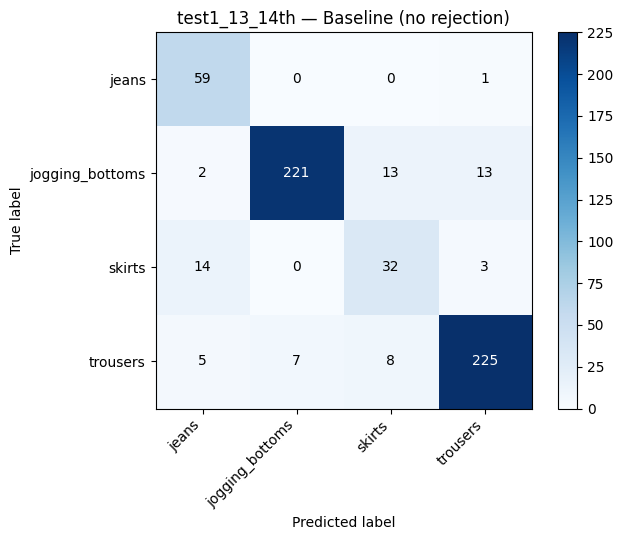


  test1_13_14th — With Per-Class Thresholds
  Total:    603
  Accepted: 564  (93.5%)
  Rejected: 39  (6.5%)
       confident:   564  (93.5%)
        rejected:    39  (6.5%)

--- Classification Report (accepted only) ---
                 precision    recall  f1-score   support

          jeans     0.7468    0.9833    0.8489        60
jogging_bottoms     0.9947    0.8750    0.9310       216
         skirts     0.6038    0.6531    0.6275        49
       trousers     0.9298    0.9414    0.9356       239

       accuracy                         0.8954       564
      macro avg     0.8188    0.8632    0.8357       564
   weighted avg     0.9069    0.8954    0.8978       564

  Accuracy (accepted): 0.8954
  Accuracy (all, rejected=wrong): 0.8375


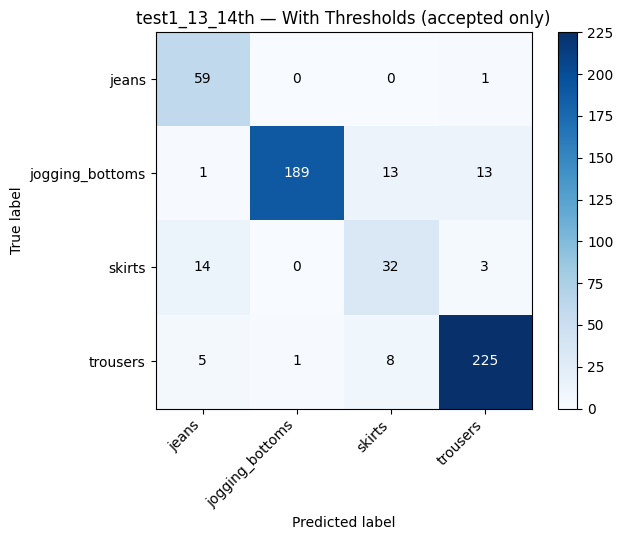

  Per-sample decisions: /content/drive/MyDrive/October_27th/model_outputs/lower_v3_base_run/inference_results/test1_13_14th_sample_decisions.csv

############################################################
  TEST SET: test2_careys
  Path: /content/drive/Shareddrives/Garment Type/Careys_labelled_data/to_test
############################################################
  Found 127 samples
    jeans             : 35
    jogging_bottoms   : 28
    skirts            : 11
    trousers          : 53


100%|██████████| 127/127 [02:15<00:00,  1.06s/it]



--- BASELINE (no rejection) ---
                 precision    recall  f1-score   support

          jeans     0.8158    0.8857    0.8493        35
jogging_bottoms     1.0000    0.7143    0.8333        28
         skirts     0.4000    0.9091    0.5556        11
       trousers     0.9545    0.7925    0.8660        53

       accuracy                         0.8110       127
      macro avg     0.7926    0.8254    0.7760       127
   weighted avg     0.8783    0.8110    0.8273       127



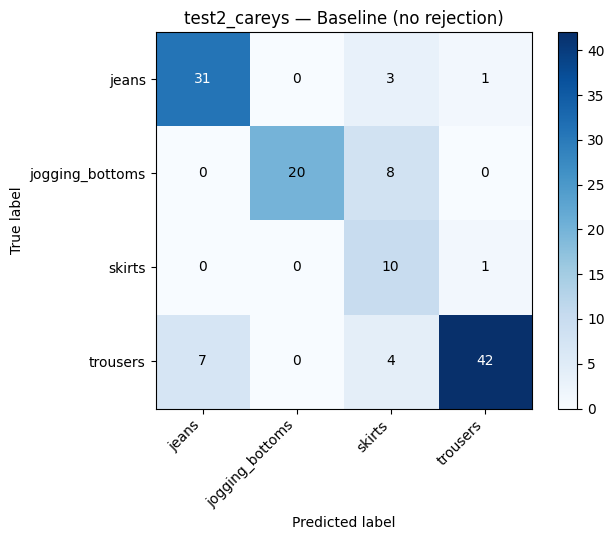


  test2_careys — With Per-Class Thresholds
  Total:    127
  Accepted: 123  (96.9%)
  Rejected: 4  (3.1%)
       confident:   123  (96.9%)
        rejected:     4  (3.1%)

--- Classification Report (accepted only) ---
                 precision    recall  f1-score   support

          jeans     0.8158    0.8857    0.8493        35
jogging_bottoms     1.0000    0.6667    0.8000        24
         skirts     0.4000    0.9091    0.5556        11
       trousers     0.9545    0.7925    0.8660        53

       accuracy                         0.8049       123
      macro avg     0.7926    0.8135    0.7677       123
   weighted avg     0.8743    0.8049    0.8206       123

  Accuracy (accepted): 0.8049
  Accuracy (all, rejected=wrong): 0.7795


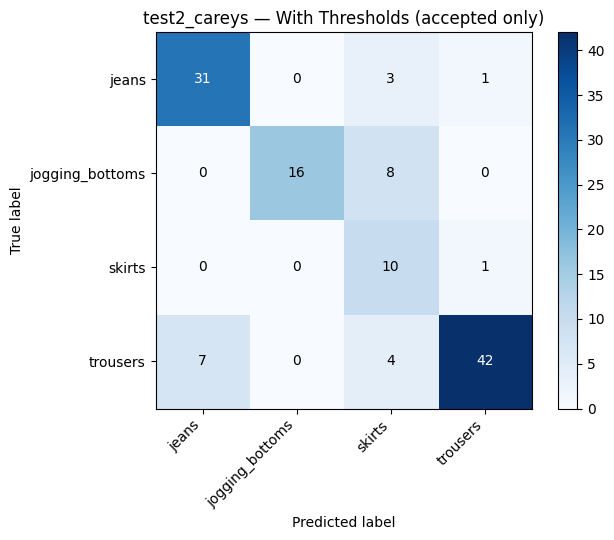

  Per-sample decisions: /content/drive/MyDrive/October_27th/model_outputs/lower_v3_base_run/inference_results/test2_careys_sample_decisions.csv

############################################################
  COMBINED (both test sets)
############################################################

--- Baseline Combined ---
                 precision    recall  f1-score   support

          jeans     0.7627    0.9474    0.8451        95
jogging_bottoms     0.9718    0.8700    0.9181       277
         skirts     0.5385    0.7000    0.6087        60
       trousers     0.9336    0.8960    0.9144       298

       accuracy                         0.8767       730
      macro avg     0.8016    0.8533    0.8216       730
   weighted avg     0.8934    0.8767    0.8816       730



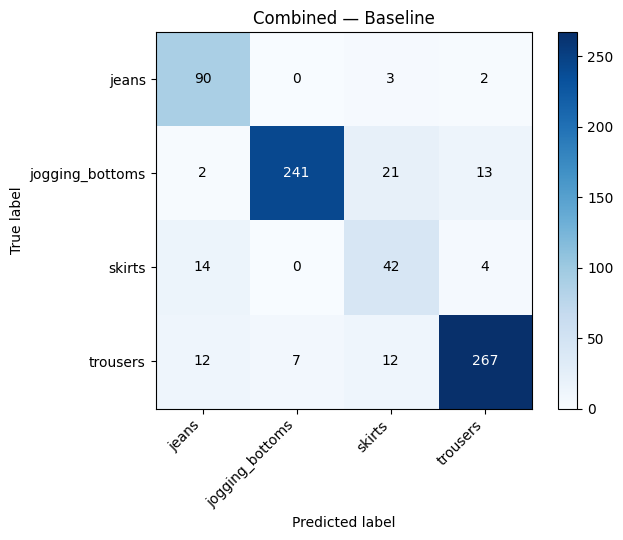


  Combined — With Per-Class Thresholds
  Total:    730
  Accepted: 687  (94.1%)
  Rejected: 43  (5.9%)
       confident:   687  (94.1%)
        rejected:    43  (5.9%)

--- Classification Report (accepted only) ---
                 precision    recall  f1-score   support

          jeans     0.7692    0.9474    0.8491        95
jogging_bottoms     0.9951    0.8542    0.9193       240
         skirts     0.5385    0.7000    0.6087        60
       trousers     0.9336    0.9144    0.9239       292

       accuracy                         0.8792       687
      macro avg     0.8091    0.8540    0.8252       687
   weighted avg     0.8978    0.8792    0.8844       687

  Accuracy (accepted): 0.8792
  Accuracy (all, rejected=wrong): 0.8274

All outputs saved in: /content/drive/MyDrive/October_27th/model_outputs/lower_v3_base_run/inference_results


In [ ]:
# ============================================================
# MAIN
# ============================================================
model, classes = load_model()
aug = build_infer_aug(IMG_SIZE)
thresholds = load_thresholds()

# Run on both test sets
r1 = evaluate_test_set("test1_13_14th", TEST_ROOT_1, model, classes, aug, thresholds)
r2 = evaluate_test_set("test2_careys", TEST_ROOT_2, model, classes, aug, thresholds)

# Combined report
if r1 and r2:
    y1_true, y1_pred, p1 = r1
    y2_true, y2_pred, p2 = r2

    y_all_true = np.concatenate([y1_true, y2_true])
    y_all_pred = np.concatenate([y1_pred, y2_pred])
    p_all = np.concatenate([p1, p2])

    print(f"\n{'#'*60}")
    print(f"  COMBINED (both test sets)")
    print(f"{'#'*60}")

    report_combined = classification_report(
        y_all_true, y_all_pred, target_names=classes, digits=4
    )
    print(f"\n--- Baseline Combined ---")
    print(report_combined)

    cm_combined = confusion_matrix(y_all_true, y_all_pred, labels=list(range(len(classes))))
    plot_confusion_matrix(
        cm_combined, classes,
        "Combined — Baseline",
        save_path=OUTDIR / "combined_baseline_cm.png"
    )

    (OUTDIR / "combined_baseline_report.txt").write_text(report_combined)

    if thresholds:
        final_all, dec_all = apply_thresholds(y_all_true, y_all_pred, p_all, classes, thresholds)
        report_with_rejection(
            y_all_true, final_all, dec_all, classes,
            title="Combined — With Per-Class Thresholds"
        )

print(f"\nAll outputs saved in: {OUTDIR}")

In [ ]:
!pip install onnx onnxruntime
import os
import json
import time
import numpy as np
from pathlib import Path

import torch
import torch.nn.functional as F
import timm
import onnx
import onnxruntime as ort

print(f"torch         : {torch.__version__}")
print(f"timm          : {timm.__version__}")
print(f"onnx          : {onnx.__version__}")
print(f"onnxruntime   : {ort.__version__}")
print(f"CUDA          : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU           : {torch.cuda.get_device_name(0)}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.5/17.5 MB 102.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 110.7 MB/s eta 0:00:00
torch         : 2.9.0+cu128
timm          : 1.0.24
onnx          : 1.20.1
onnxruntime   : 1.24.1
CUDA          : True
GPU           : NVIDIA A100-SXM4-80GB


In [ ]:
# ============================================================
# PATHS
# ============================================================
UPPER_DIR = Path("/content/drive/MyDrive/October_27th/model_outputs/upper_v3_run_opus")
LOWER_DIR = Path("/content/drive/MyDrive/October_27th/model_outputs/lower_v3_base_run")

MODELS = {
    "lower_v3": {
        "ckpt": LOWER_DIR / "best_lower_cnn.pth",
        "backbone": "convnextv2_base.fcmae_ft_in22k_in1k_384",
        "img_size": 384,
        "classes": ["jeans", "jogging_bottoms", "skirts", "trousers"],
        "onnx_out": LOWER_DIR / "lower_v3.onnx",
        "thresholds": LOWER_DIR / "lower_per_class_thresholds.json",
    },
}

OPSET = 17
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Verify all checkpoints exist
for name, cfg in MODELS.items():
    assert cfg["ckpt"].exists(), f"Missing checkpoint: {cfg['ckpt']}"
    print(f"✓ {name}: {cfg['ckpt'].name} ({cfg['backbone']}, {cfg['img_size']}px, {len(cfg['classes'])} classes)")

✓ lower_v3: best_lower_cnn.pth (convnextv2_base.fcmae_ft_in22k_in1k_384, 384px, 4 classes)


In [ ]:
def load_pytorch_model(cfg):
    """Load a trained PyTorch model from checkpoint."""
    ckpt = torch.load(cfg["ckpt"], map_location=DEVICE, weights_only=False)

    model = timm.create_model(
        cfg["backbone"],
        pretrained=False,
        num_classes=len(cfg["classes"])
    )
    model.load_state_dict(ckpt["model_state"], strict=True)
    model.to(DEVICE)
    model.eval()

    n_params = sum(p.numel() for p in model.parameters()) / 1e6
    print(f"  Loaded: {cfg['backbone']} — {n_params:.1f}M params")
    print(f"  Best F1 (train): {ckpt.get('best_f1', 'N/A')}")
    return model


def export_to_onnx(model, cfg, opset=17):
    """Export PyTorch model to ONNX with dynamic batch size."""
    img_size = cfg["img_size"]
    onnx_path = cfg["onnx_out"]

    # Dummy input
    dummy = torch.randn(1, 3, img_size, img_size, device=DEVICE)

    # Export
    print(f"  Exporting to: {onnx_path}")
    torch.onnx.export(
        model,
        dummy,
        str(onnx_path),
        opset_version=opset,
        input_names=["input"],
        output_names=["logits"],
        dynamic_axes={
            "input": {0: "batch_size"},
            "logits": {0: "batch_size"},
        },
    )

    # Validate
    onnx_model = onnx.load(str(onnx_path))
    onnx.checker.check_model(onnx_model)

    size_mb = os.path.getsize(onnx_path) / (1024 * 1024)
    print(f"  ✓ ONNX valid — {size_mb:.1f} MB")
    print(f"  Opset: {opset}")
    print(f"  Input:  input  → [batch, 3, {img_size}, {img_size}]")
    print(f"  Output: logits → [batch, {len(cfg['classes'])}]")

    return onnx_path


def validate_onnx(model, cfg):
    """Compare PyTorch vs ONNX Runtime outputs."""
    img_size = cfg["img_size"]
    onnx_path = str(cfg["onnx_out"])

    # PyTorch inference
    dummy = torch.randn(1, 3, img_size, img_size, device=DEVICE)
    with torch.no_grad():
        pt_logits = model(dummy).cpu().numpy()

    # ONNX Runtime inference
    providers = ["CUDAExecutionProvider", "CPUExecutionProvider"]
    session = ort.InferenceSession(onnx_path, providers=providers)
    ort_logits = session.run(
        ["logits"],
        {"input": dummy.cpu().numpy()}
    )[0]

    # Compare
    max_diff = np.abs(pt_logits - ort_logits).max()
    mean_diff = np.abs(pt_logits - ort_logits).mean()
    pt_pred = pt_logits.argmax(1)
    ort_pred = ort_logits.argmax(1)
    preds_match = (pt_pred == ort_pred).all()

    print(f"  Max  abs diff: {max_diff:.8f}")
    print(f"  Mean abs diff: {mean_diff:.8f}")
    print(f"  Predictions match: {preds_match}")

    if max_diff < 1e-4:
        print(f"  ✓ Outputs match within tolerance")
    else:
        print(f"  ⚠ Outputs differ beyond 1e-4 — check model")

    return session


def benchmark_onnx(cfg, n_warmup=10, n_runs=50):
    """Benchmark ONNX Runtime latency."""
    img_size = cfg["img_size"]
    onnx_path = str(cfg["onnx_out"])

    providers = ["CUDAExecutionProvider", "CPUExecutionProvider"]
    session = ort.InferenceSession(onnx_path, providers=providers)

    active = session.get_providers()
    print(f"  Active providers: {active}")

    dummy_np = np.random.randn(1, 3, img_size, img_size).astype(np.float32)

    # Warmup
    for _ in range(n_warmup):
        session.run(["logits"], {"input": dummy_np})

    # Benchmark
    times = []
    for _ in range(n_runs):
        t0 = time.perf_counter()
        session.run(["logits"], {"input": dummy_np})
        times.append((time.perf_counter() - t0) * 1000)

    times = np.array(times)
    print(f"  Latency (ms): mean={times.mean():.1f}, median={np.median(times):.1f}, "
          f"p95={np.percentile(times, 95):.1f}, min={times.min():.1f}, max={times.max():.1f}")
    print(f"  Throughput: ~{1000/times.mean():.0f} img/s (batch=1)")

    return times

In [ ]:
!pip install onnxscript
print("=" * 60)
print("  LOWER V3 — ConvNeXt-V2-Base (384px)")
print("=" * 60)

cfg = MODELS["lower_v3"]
lower_model = load_pytorch_model(cfg)
print()
export_to_onnx(lower_model, cfg, opset=OPSET)
print()
validate_onnx(lower_model, cfg)
print()
benchmark_onnx(cfg)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 48.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.3/159.3 kB 20.0 MB/s eta 0:00:00
  LOWER V3 — ConvNeXt-V2-Base (384px)
  Loaded: convnextv2_base.fcmae_ft_in22k_in1k_384 — 87.7M params
  Best F1 (train): 0.8994173781430915

  Exporting to: /content/drive/MyDrive/October_27th/model_outputs/lower_v3_base_run/lower_v3.onnx


/tmp/ipython-input-3488751374.py:30: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0212 10:10:53.848000 1540 torch/onnx/_internal/exporter/_compat.py:114] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0212 10:10:54.895000 1540 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, al

[torch.onnx] Obtain model graph for `ConvNeXt([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `ConvNeXt([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...
[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...


[torch.onnx] Translate the graph into ONNX... ✅


Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 120, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 115, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_str, target_version)
                          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: /github/workspace/onnx/version_converter/adapters/axes_input_to_attribute.h:65: adapt: Asserti

  ✓ ONNX valid — 1.7 MB
  Opset: 17
  Input:  input  → [batch, 3, 384, 384]
  Output: logits → [batch, 4]



/usr/local/lib/python3.12/dist-packages/onnxruntime/capi/onnxruntime_inference_collection.py:123: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


  Max  abs diff: 0.00006189
  Mean abs diff: 0.00002821
  Predictions match: True
  ✓ Outputs match within tolerance

  Active providers: ['CPUExecutionProvider']
  Latency (ms): mean=360.5, median=377.4, p95=410.7, min=306.7, max=441.8
  Throughput: ~3 img/s (batch=1)


array([326.447914, 331.376556, 320.531179, 392.447927, 391.800287,
       390.470644, 392.797775, 395.771916, 403.744258, 403.783536,
       403.313644, 403.980174, 400.465029, 396.746387, 339.095689,
       312.385511, 335.866872, 324.559289, 322.311095, 317.910939,
       316.461353, 313.856423, 323.197953, 322.448119, 309.049562,
       311.737282, 319.586854, 306.67869 , 309.928366, 306.940211,
       314.793343, 334.301285, 381.127548, 314.492329, 307.172378,
       373.864336, 393.145645, 394.847667, 398.008668, 341.731591,
       380.846652, 393.724077, 390.034188, 415.07403 , 396.82062 ,
       410.902004, 410.415149, 441.783467, 402.355573, 383.284595])

In [ ]:
for name, cfg in MODELS.items():
    # Load thresholds if available
    thresholds = {}
    if cfg["thresholds"].exists():
        with open(cfg["thresholds"]) as f:
            tdata = json.load(f)
        thresholds = tdata.get("thresholds", {})

    meta = {
        "model_name": name,
        "backbone": cfg["backbone"],
        "onnx_file": cfg["onnx_out"].name,
        "opset": OPSET,
        "input_name": "input",
        "output_name": "logits",
        "input_shape": [1, 3, cfg["img_size"], cfg["img_size"]],
        "dynamic_batch": True,
        "classes": cfg["classes"],
        "num_classes": len(cfg["classes"]),
        "preprocessing": {
            "resize": [cfg["img_size"], cfg["img_size"]],
            "normalize_mean": [0.485, 0.456, 0.406],
            "normalize_std": [0.229, 0.224, 0.225],
            "channel_order": "RGB",
            "tensor_format": "NCHW",
            "dtype": "float32",
        },
        "thresholds": thresholds,
    }

    meta_path = cfg["onnx_out"].with_suffix(".json")
    with open(meta_path, "w") as f:
        json.dump(meta, f, indent=2)

    print(f"✓ {name}: {meta_path}")
    print(f"  Classes: {cfg['classes']}")
    print(f"  Thresholds: {thresholds}")
    print()

✓ lower_v3: /content/drive/MyDrive/October_27th/model_outputs/lower_v3_base_run/lower_v3.json
  Classes: ['jeans', 'jogging_bottoms', 'skirts', 'trousers']
  Thresholds: {'jeans': 0.32, 'jogging_bottoms': 0.5, 'skirts': 0.2, 'trousers': 0.2}



In [ ]:
print("\n" + "=" * 60)
print("  EXPORT SUMMARY")
print("=" * 60)

for name, cfg in MODELS.items():
    onnx_path = cfg["onnx_out"]
    meta_path = onnx_path.with_suffix(".json")
    size_mb = os.path.getsize(onnx_path) / (1024 * 1024)

    print(f"\n  {name}:")
    print(f"    ONNX:      {onnx_path} ({size_mb:.1f} MB)")
    print(f"    Metadata:  {meta_path}")
    print(f"    Backbone:  {cfg['backbone']}")
    print(f"    Input:     [batch, 3, {cfg['img_size']}, {cfg['img_size']}]")
    print(f"    Classes:   {cfg['classes']}")

print(f"\n{'='*60}")
print("  All exports complete!")
print("="*60)


  EXPORT SUMMARY

  lower_v3:
    ONNX:      /content/drive/MyDrive/October_27th/model_outputs/lower_v3_base_run/lower_v3.onnx (1.7 MB)
    Metadata:  /content/drive/MyDrive/October_27th/model_outputs/lower_v3_base_run/lower_v3.json
    Backbone:  convnextv2_base.fcmae_ft_in22k_in1k_384
    Input:     [batch, 3, 384, 384]
    Classes:   ['jeans', 'jogging_bottoms', 'skirts', 'trousers']

  All exports complete!


In [ ]:
# ============================================================
# PATHS
# ============================================================
TEST_ROOT_1 = Path("/content/drive/Shareddrives/Garment Type/classified_images_13_14_test/13_14th_test")
TEST_ROOT_2 = Path("/content/drive/Shareddrives/Garment Type/Careys_labelled_data/to_test")

UPPER_DIR = Path("/content/drive/MyDrive/October_27th/model_outputs/upper_v3_run_opus")
LOWER_DIR = Path("/content/drive/MyDrive/October_27th/model_outputs/lower_v3_base_run")

MODELS = {
    "lower_v3": {
        "pt_ckpt": LOWER_DIR / "best_lower_cnn.pth",
        "onnx_path": LOWER_DIR / "lower_v3.onnx",
        "backbone": "convnextv2_base.fcmae_ft_in22k_in1k_384",
        "img_size": 384,
        "classes": ["jeans", "jogging_bottoms", "skirts", "trousers"],
        "branch_folder": "lower",
    },
}

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Verify files exist
for name, cfg in MODELS.items():
    assert cfg["pt_ckpt"].exists(), f"Missing .pt: {cfg['pt_ckpt']}"
    assert cfg["onnx_path"].exists(), f"Missing .onnx: {cfg['onnx_path']}"
    pt_mb = os.path.getsize(cfg["pt_ckpt"]) / (1024**2)
    onnx_mb = os.path.getsize(cfg["onnx_path"]) / (1024**2)
    print(f"✓ {name}: .pt={pt_mb:.1f}MB  .onnx={onnx_mb:.1f}MB")

✓ lower_v3: .pt=334.7MB  .onnx=1.7MB


In [ ]:
def build_transform(img_size):
    return A.Compose([
        A.Resize(img_size, img_size),
        A.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
        ToTensorV2()
    ])


def collect_samples(test_root, branch_folder):
    """Collect (path, label) from test_root/branch_folder/class_name/"""
    samples = []
    branch_dir = test_root / branch_folder
    if not branch_dir.exists():
        return samples
    for cls in sorted(os.listdir(branch_dir)):
        cls_dir = branch_dir / cls
        if not cls_dir.is_dir():
            continue
        for img in cls_dir.iterdir():
            if img.is_file():
                samples.append((str(img), cls.lower()))
    return samples


def load_pt_model(cfg):
    """Load PyTorch model from checkpoint."""
    ckpt = torch.load(cfg["pt_ckpt"], map_location=DEVICE, weights_only=False)
    model = timm.create_model(
        cfg["backbone"],
        pretrained=False,
        num_classes=len(cfg["classes"])
    )
    model.load_state_dict(ckpt["model_state"], strict=True)
    model.to(DEVICE)
    model.eval()
    return model


def load_onnx_session(cfg):
    """Load ONNX Runtime session."""
    providers = ["CUDAExecutionProvider", "CPUExecutionProvider"]
    session = ort.InferenceSession(str(cfg["onnx_path"]), providers=providers)
    active = session.get_providers()
    print(f"  ORT providers: {active}")
    return session


def preprocess_image(path, transform, img_size):
    """Load and preprocess a single image."""
    try:
        img = Image.open(path).convert("RGB")
        img_np = np.array(img)
    except:
        img_np = np.zeros((img_size, img_size, 3), dtype=np.uint8)
    tensor = transform(image=img_np)["image"]
    return tensor

In [ ]:
def verify_model(model_name, cfg, test_roots):
    """
    Full verification: run every test image through both .pt and .onnx,
    compare predictions, logits, and classification reports.
    """
    print(f"\n{'#'*70}")
    print(f"  VERIFYING: {model_name}")
    print(f"  Backbone: {cfg['backbone']}  |  Resolution: {cfg['img_size']}px")
    print(f"  Classes: {cfg['classes']}")
    print(f"{'#'*70}")

    classes = cfg["classes"]
    cls2idx = {c: i for i, c in enumerate(classes)}
    img_size = cfg["img_size"]
    transform = build_transform(img_size)

    # Load both models
    print(f"\n  Loading PyTorch model...")
    pt_model = load_pt_model(cfg)
    print(f"  Loading ONNX session...")
    ort_session = load_onnx_session(cfg)

    # Collect all test samples across test sets
    all_results = {}

    for test_name, test_root in test_roots.items():
        samples = collect_samples(test_root, cfg["branch_folder"])
        if not samples:
            print(f"\n  [{test_name}] No samples found in {test_root}/{cfg['branch_folder']}, skipping.")
            continue

        print(f"\n  {'='*60}")
        print(f"  [{test_name}] — {len(samples)} images")
        print(f"  {'='*60}")

        dist = Counter(c for _, c in samples)
        for cls, cnt in sorted(dist.items()):
            print(f"    {cls:18s}: {cnt}")

        # Run inference
        gt_labels = []
        pt_preds = []
        ort_preds = []
        pt_probs_all = []
        ort_probs_all = []
        max_diffs = []
        mismatches = []

        with torch.no_grad():
            for path, gt in tqdm(samples, desc=f"  {test_name}"):
                if gt.lower() not in cls2idx:
                    continue

                tensor = preprocess_image(path, transform, img_size)

                # --- PyTorch ---
                x_pt = tensor.unsqueeze(0).to(DEVICE)
                with torch.cuda.amp.autocast():
                    pt_logits = pt_model(x_pt)[0]
                pt_probs = torch.softmax(pt_logits, dim=0).cpu().numpy()
                pt_pred = int(pt_probs.argmax())

                # --- ONNX Runtime ---
                x_ort = tensor.unsqueeze(0).numpy()
                ort_logits = ort_session.run(["logits"], {"input": x_ort})[0][0]
                # softmax on numpy
                ort_exp = np.exp(ort_logits - ort_logits.max())
                ort_probs = ort_exp / ort_exp.sum()
                ort_pred = int(ort_probs.argmax())

                gt_idx = cls2idx[gt.lower()]
                gt_labels.append(gt_idx)
                pt_preds.append(pt_pred)
                ort_preds.append(ort_pred)
                pt_probs_all.append(pt_probs)
                ort_probs_all.append(ort_probs)

                diff = np.abs(pt_probs - ort_probs).max()
                max_diffs.append(diff)

                if pt_pred != ort_pred:
                    mismatches.append({
                        "path": path,
                        "gt": classes[gt_idx],
                        "pt_pred": classes[pt_pred],
                        "ort_pred": classes[ort_pred],
                        "pt_conf": float(pt_probs[pt_pred]),
                        "ort_conf": float(ort_probs[ort_pred]),
                        "max_prob_diff": float(diff),
                    })

        gt_labels = np.array(gt_labels)
        pt_preds = np.array(pt_preds)
        ort_preds = np.array(ort_preds)
        max_diffs = np.array(max_diffs)

        # ---- Results ----
        n_total = len(gt_labels)
        n_match = (pt_preds == ort_preds).sum()
        match_rate = n_match / n_total * 100

        print(f"\n  --- Prediction Match ---")
        print(f"  Total images:    {n_total}")
        print(f"  Predictions match: {n_match}/{n_total} ({match_rate:.2f}%)")
        print(f"  Mismatches:      {len(mismatches)}")

        print(f"\n  --- Probability Differences ---")
        print(f"  Max  diff: {max_diffs.max():.8f}")
        print(f"  Mean diff: {max_diffs.mean():.8f}")
        print(f"  P95  diff: {np.percentile(max_diffs, 95):.8f}")
        print(f"  P99  diff: {np.percentile(max_diffs, 99):.8f}")

        # Classification reports
        print(f"\n  --- PyTorch Classification Report ---")
        pt_report = classification_report(gt_labels, pt_preds, target_names=classes, digits=4)
        print(pt_report)

        print(f"  --- ONNX Classification Report ---")
        ort_report = classification_report(gt_labels, ort_preds, target_names=classes, digits=4)
        print(ort_report)

        # F1 comparison
        from sklearn.metrics import f1_score, accuracy_score
        pt_f1 = f1_score(gt_labels, pt_preds, average="macro")
        ort_f1 = f1_score(gt_labels, ort_preds, average="macro")
        pt_acc = accuracy_score(gt_labels, pt_preds)
        ort_acc = accuracy_score(gt_labels, ort_preds)

        print(f"  --- Summary ---")
        print(f"  {'Metric':<20s} {'PyTorch':>10s} {'ONNX':>10s} {'Δ':>10s}")
        print(f"  {'-'*50}")
        print(f"  {'Macro F1':<20s} {pt_f1:>10.4f} {ort_f1:>10.4f} {ort_f1-pt_f1:>+10.4f}")
        print(f"  {'Accuracy':<20s} {pt_acc:>10.4f} {ort_acc:>10.4f} {ort_acc-pt_acc:>+10.4f}")

        if match_rate == 100.0:
            print(f"\n  ✓ PERFECT MATCH — safe to proceed to TensorRT")
        elif match_rate >= 99.5:
            print(f"\n  ✓ NEAR-PERFECT — {len(mismatches)} edge-case mismatches, acceptable for TRT conversion")
        else:
            print(f"\n  ⚠ SIGNIFICANT MISMATCHES — investigate before TRT conversion")

        # Show mismatches if any
        if mismatches:
            print(f"\n  --- Mismatch Details ---")
            for m in mismatches:
                fname = Path(m['path']).name
                print(f"    {fname}: GT={m['gt']}, PT={m['pt_pred']}({m['pt_conf']:.3f}), "
                      f"ORT={m['ort_pred']}({m['ort_conf']:.3f}), prob_diff={m['max_prob_diff']:.6f}")

        all_results[test_name] = {
            "n_total": n_total,
            "n_match": int(n_match),
            "match_rate": match_rate,
            "max_prob_diff": float(max_diffs.max()),
            "mean_prob_diff": float(max_diffs.mean()),
            "pt_f1": pt_f1,
            "ort_f1": ort_f1,
            "pt_acc": pt_acc,
            "ort_acc": ort_acc,
            "mismatches": mismatches,
        }

    # Plot probability difference distribution
    if all_results:
        fig, ax = plt.subplots(figsize=(8, 3.5))
        all_diffs = np.concatenate([np.array([m["max_prob_diff"] for m in r["mismatches"]])
                                     if r["mismatches"] else np.array([0.0])
                                     for r in all_results.values()])
        # Recompute from all max_diffs
        ax.set_title(f"{model_name}: Max Probability Diff per Image (.pt vs .onnx)")
        ax.set_xlabel("Max |prob_pt - prob_onnx|")
        ax.set_ylabel("Count")
        ax.text(0.98, 0.95,
                f"Match rate: {sum(r['n_match'] for r in all_results.values())}/"
                f"{sum(r['n_total'] for r in all_results.values())}",
                transform=ax.transAxes, ha="right", va="top", fontsize=11,
                bbox=dict(boxstyle="round", facecolor="lightgreen" if all(
                    r["match_rate"] >= 99.5 for r in all_results.values()) else "lightyellow"))
        plt.tight_layout()
        plt.show()

    # Cleanup
    del pt_model
    torch.cuda.empty_cache()

    return all_results

In [ ]:
import albumentations as A
from albumentations.pytorch import ToTensorV2
test_roots = {
    "test1_13_14th": TEST_ROOT_1,
    "test2_careys": TEST_ROOT_2,
}

lower_results = verify_model("lower_v3", MODELS["lower_v3"], test_roots)


######################################################################
  VERIFYING: lower_v3
  Backbone: convnextv2_base.fcmae_ft_in22k_in1k_384  |  Resolution: 384px
  Classes: ['jeans', 'jogging_bottoms', 'skirts', 'trousers']
######################################################################

  Loading PyTorch model...
  Loading ONNX session...


/usr/local/lib/python3.12/dist-packages/onnxruntime/capi/onnxruntime_inference_collection.py:123: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


  ORT providers: ['CPUExecutionProvider']

  [test1_13_14th] — 603 images


NameError: name 'Counter' is not defined

In [ ]:
print("\n" + "=" * 70)
print("  ONNX VERIFICATION SUMMARY")
print("=" * 70)

all_pass = True

for model_name, results in [("lower_v3", lower_results)]:
    print(f"\n  {model_name}:")
    for test_name, r in results.items():
        status = "✓" if r["match_rate"] >= 99.5 else "⚠"
        if r["match_rate"] < 99.5:
            all_pass = False
        print(f"    {status} {test_name}: {r['n_match']}/{r['n_total']} match "
              f"({r['match_rate']:.2f}%) | "
              f"F1: .pt={r['pt_f1']:.4f} .onnx={r['ort_f1']:.4f} (Δ={r['ort_f1']-r['pt_f1']:+.4f}) | "
              f"max_prob_diff={r['max_prob_diff']:.6f}")

print(f"\n{'='*70}")
if all_pass:
    print("  ✓ ALL MODELS VERIFIED — safe to proceed to TensorRT conversion")
else:
    print("  ⚠ SOME MODELS HAVE MISMATCHES — review before TRT conversion")
print("=" * 70)

In [ ]:
import os
import shutil
import numpy as np
from pathlib import Path

import torch
import torch.nn as nn
import timm
import onnx
from onnxsim import simplify
import onnxruntime as ort

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
OPSET = 17

# >>>>>>>>>> EDIT PATHS HERE <<<<<<<<
LOWER_DIR = Path("/content/drive/MyDrive/October_27th/model_outputs/lower_v3_base_run")
CKPT      = LOWER_DIR / "best_lower_cnn.pth"
BACKBONE  = "convnextv2_base.fcmae_ft_in22k_in1k_384"
IMG_SIZE  = 384
CLASSES   = ["jeans", "jogging_bottoms", "skirts", "trousers"]
ONNX_NAME = "lower_v3_trt.onnx"


class TRTCompatibleWrapper(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x):
        x = self.model.forward_features(x)
        x = x.mean(dim=(-2, -1), keepdim=True)
        head = self.model.head
        if hasattr(head, 'norm') and head.norm is not None:
            x = head.norm(x)
        x = x.flatten(1)
        if hasattr(head, 'pre_logits') and head.pre_logits is not None:
            x = head.pre_logits(x)
        if hasattr(head, 'drop') and head.drop is not None:
            x = head.drop(x)
        if hasattr(head, 'fc') and head.fc is not None:
            x = head.fc(x)
        return x


# Load model
ckpt = torch.load(CKPT, map_location=DEVICE, weights_only=False)
model = timm.create_model(BACKBONE, pretrained=False, num_classes=len(CLASSES))
model.load_state_dict(ckpt["model_state"], strict=True)
model.to(DEVICE).eval()
print(f"✓ Loaded (F1={ckpt.get('best_f1', 'N/A')})")

# Validate wrapper
wrapper = TRTCompatibleWrapper(model).to(DEVICE).eval()
dummy = torch.randn(1, 3, IMG_SIZE, IMG_SIZE, device=DEVICE)
with torch.no_grad():
    diff = (model(dummy) - wrapper(dummy)).abs().max().item()
print(f"Wrapper diff: {diff:.10f}")
assert diff < 1e-4, f"Mismatch: {diff}"
print("✓ Wrapper validated")

# Export to local
local_onnx = f"/content/{ONNX_NAME}"
torch.onnx.export(
    wrapper, dummy, local_onnx,
    opset_version=OPSET,
    input_names=["input"], output_names=["logits"],
    dynamic_axes={"input": {0: "batch"}, "logits": {0: "batch"}},
    do_constant_folding=True, dynamo=False,
)

# Simplify
onnx_model = onnx.load(local_onnx)
onnx_sim, check = simplify(onnx_model)
assert check, "onnxsim failed"
onnx.save(onnx_sim, local_onnx)

# Check ops
ops = set(n.op_type for n in onnx.load(local_onnx).graph.node)
bad = ops & {"SequenceEmpty", "SequenceConstruct", "SequenceAt", "SequenceInsert", "ConcatFromSequence"}
print(f"Ops: {sorted(ops)}")
print(f"✓ No bad ops" if not bad else f"⚠ Bad ops: {bad}")
print(f"Local: {local_onnx} ({os.path.getsize(local_onnx)/(1024*1024):.1f} MB)")

# Validate ONNX vs PyTorch
session = ort.InferenceSession(local_onnx, providers=["CUDAExecutionProvider", "CPUExecutionProvider"])
with torch.no_grad():
    pt = model(dummy).cpu().numpy()
ort_out = session.run(["logits"], {"input": dummy.cpu().numpy()})[0]
print(f"Max diff: {np.abs(pt - ort_out).max():.8f} | Preds match: {(pt.argmax(1) == ort_out.argmax(1)).all()}")

# Dynamic batch test
batch_out = session.run(["logits"], {"input": torch.randn(4, 3, IMG_SIZE, IMG_SIZE).numpy()})[0]
print(f"✓ Dynamic batch: {batch_out.shape}")
del session

# Copy to Drive
final = str(LOWER_DIR / ONNX_NAME)
for f in [final, final + ".data"]:
    if os.path.exists(f):
        os.remove(f)
shutil.copy2(local_onnx, final)
if os.path.exists(local_onnx + ".data"):
    shutil.copy2(local_onnx + ".data", final + ".data")
    print(f"✓ Copied to Drive: {final} + .data")
else:
    print(f"✓ Copied to Drive: {final} (single file)")

print(f"\n✅ READY — copy to Jetson and run:")
print(f"  /usr/src/tensorrt/bin/trtexec \\")
print(f"      --onnx={ONNX_NAME} --saveEngine=lower_v3.engine \\")
print(f"      --fp16 --minShapes=input:1x3x384x384 \\")
print(f"      --optShapes=input:1x3x384x384 --maxShapes=input:4x3x384x384 \\")
print(f"      --memPoolSize=workspace:2048M")

✓ Loaded (F1=0.8994173781430915)
Wrapper diff: 0.0000000000
✓ Wrapper validated


/tmp/ipython-input-3848718999.py:64: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter will be the default. To switch now, set dynamo=True in torch.onnx.export. This new exporter supports features like exporting LLMs with DynamicCache. We encourage you to try it and share feedback to help improve the experience. Learn more about the new export logic: https://pytorch.org/docs/stable/onnx_dynamo.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html.
  torch.onnx.export(


Ops: ['Add', 'Conv', 'Div', 'Erf', 'Flatten', 'Gemm', 'LayerNormalization', 'MatMul', 'Mul', 'ReduceL2', 'ReduceMean', 'Transpose']
✓ No bad ops
Local: /content/lower_v3_trt.onnx (334.8 MB)


/usr/local/lib/python3.12/dist-packages/onnxruntime/capi/onnxruntime_inference_collection.py:123: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


Max diff: 0.00006136 | Preds match: True
✓ Dynamic batch: (4, 4)
✓ Copied to Drive: /content/drive/MyDrive/October_27th/model_outputs/lower_v3_base_run/lower_v3_trt.onnx (single file)

✅ READY — copy to Jetson and run:
  /usr/src/tensorrt/bin/trtexec \
      --onnx=lower_v3_trt.onnx --saveEngine=lower_v3.engine \
      --fp16 --minShapes=input:1x3x384x384 \
      --optShapes=input:1x3x384x384 --maxShapes=input:4x3x384x384 \
      --memPoolSize=workspace:2048M


In [ ]:
import os
import json
import timeimport os
import shutil
import numpy as np
from pathlib import Path

import torch
import torch.nn as nn
import timm
import onnx
from onnxsim import simplify
import onnxruntime as ort

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
OPSET = 17

# >>>>>>>>>> EDIT PATHS HERE <<<<<<<<
LOWER_DIR = Path("/content/drive/MyDrive/October_27th/model_outputs/lower_v3_base_run")
CKPT      = LOWER_DIR / "best_lower_cnn.pth"
BACKBONE  = "convnextv2_base.fcmae_ft_in22k_in1k_384"
IMG_SIZE  = 384
CLASSES   = ["jeans", "jogging_bottoms", "skirts", "trousers"]
ONNX_NAME = "lower_v3_trt.onnx"


class TRTCompatibleWrapper(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x):
        x = self.model.forward_features(x)
        x = x.mean(dim=(-2, -1), keepdim=True)
        head = self.model.head
        if hasattr(head, 'norm') and head.norm is not None:
            x = head.norm(x)
        x = x.flatten(1)
        if hasattr(head, 'pre_logits') and head.pre_logits is not None:
            x = head.pre_logits(x)
        if hasattr(head, 'drop') and head.drop is not None:
            x = head.drop(x)
        if hasattr(head, 'fc') and head.fc is not None:
            x = head.fc(x)
        return x


# Load model
ckpt = torch.load(CKPT, map_location=DEVICE, weights_only=False)
model = timm.create_model(BACKBONE, pretrained=False, num_classes=len(CLASSES))
model.load_state_dict(ckpt["model_state"], strict=True)
model.to(DEVICE).eval()
print(f"✓ Loaded (F1={ckpt.get('best_f1', 'N/A')})")

# Validate wrapper
wrapper = TRTCompatibleWrapper(model).to(DEVICE).eval()
dummy = torch.randn(1, 3, IMG_SIZE, IMG_SIZE, device=DEVICE)
with torch.no_grad():
    diff = (model(dummy) - wrapper(dummy)).abs().max().item()
print(f"Wrapper diff: {diff:.10f}")
assert diff < 1e-4, f"Mismatch: {diff}"
print("✓ Wrapper validated")

# Export to local
local_onnx = f"/content/{ONNX_NAME}"
torch.onnx.export(
    wrapper, dummy, local_onnx,
    opset_version=OPSET,
    input_names=["input"], output_names=["logits"],
    dynamic_axes={"input": {0: "batch"}, "logits": {0: "batch"}},
    do_constant_folding=True, dynamo=False,
)

# Simplify
onnx_model = onnx.load(local_onnx)
onnx_sim, check = simplify(onnx_model)
assert check, "onnxsim failed"
onnx.save(onnx_sim, local_onnx)

# Check ops
ops = set(n.op_type for n in onnx.load(local_onnx).graph.node)
bad = ops & {"SequenceEmpty", "SequenceConstruct", "SequenceAt", "SequenceInsert", "ConcatFromSequence"}
print(f"Ops: {sorted(ops)}")
print(f"✓ No bad ops" if not bad else f"⚠ Bad ops: {bad}")
print(f"Local: {local_onnx} ({os.path.getsize(local_onnx)/(1024*1024):.1f} MB)")

# Validate ONNX vs PyTorch
session = ort.InferenceSession(local_onnx, providers=["CUDAExecutionProvider", "CPUExecutionProvider"])
with torch.no_grad():
    pt = model(dummy).cpu().numpy()
ort_out = session.run(["logits"], {"input": dummy.cpu().numpy()})[0]
print(f"Max diff: {np.abs(pt - ort_out).max():.8f} | Preds match: {(pt.argmax(1) == ort_out.argmax(1)).all()}")

# Dynamic batch test
batch_out = session.run(["logits"], {"input": torch.randn(4, 3, IMG_SIZE, IMG_SIZE).numpy()})[0]
print(f"✓ Dynamic batch: {batch_out.shape}")
del session

# Copy to Drive
final = str(LOWER_DIR / ONNX_NAME)
for f in [final, final + ".data"]:
    if os.path.exists(f):
        os.remove(f)
shutil.copy2(local_onnx, final)
if os.path.exists(local_onnx + ".data"):
    shutil.copy2(local_onnx + ".data", final + ".data")
    print(f"✓ Copied to Drive: {final} + .data")
else:
    print(f"✓ Copied to Drive: {final} (single file)")

print(f"\n✅ READY — copy to Jetson and run:")
print(f"  /usr/src/tensorrt/bin/trtexec \\")
print(f"      --onnx={ONNX_NAME} --saveEngine=lower_v3.engine \\")
print(f"      --fp16 --minShapes=input:1x3x384x384 \\")
print(f"      --optShapes=input:1x3x384x384 --maxShapes=input:4x3x384x384 \\")
print(f"      --memPoolSize=workspace:2048M")
from pathlib import Path

import numpy as np
import torch
import timm
!pip install onnx onnxruntime onnxscript
import matplotlib.pyplot as plt
import onnx
import onnxruntime as ort

# ============================================================
# CONFIGURATION
# ============================================================
LOWER_DIR = Path("/content/drive/MyDrive/October_27th/model_outputs/lower_v3_base_run")

MODELS = {
    "lower_v3": {
        "ckpt": LOWER_DIR / "best_lower_cnn.pth",
        "backbone": "convnextv2_base.fcmae_ft_in22k_in1k_384",
        "img_size": 384,
        "classes": ["jeans", "jogging_bottoms", "skirts", "trousers"],
        "onnx_out": LOWER_DIR / "lower_v3.onnx",
        "thresholds": LOWER_DIR / "lower_per_class_thresholds.json",
    },
}

OPSET = 17
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
EXPORT_BATCH = 4
VERIFY_BATCHES = [1, 4]


# ============================================================
# HELPER FUNCTIONS
# ============================================================
def load_pytorch_model(cfg):
    """Load a trained PyTorch model from checkpoint."""
    ckpt = torch.load(cfg["ckpt"], map_location=DEVICE, weights_only=False)

    model = timm.create_model(
        cfg["backbone"],
        pretrained=False,
        num_classes=len(cfg["classes"])
    )
    model.load_state_dict(ckpt["model_state"], strict=True)
    model.to(DEVICE)
    model.eval()

    n_params = sum(p.numel() for p in model.parameters()) / 1e6
    print(f"  Loaded: {cfg['backbone']} — {n_params:.1f}M params")
    print(f"  Best F1 (train): {ckpt.get('best_f1', 'N/A')}")
    return model, ckpt


def inspect_onnx_io(onnx_path):
    """Print ONNX input/output shapes."""
    model = onnx.load(str(onnx_path))

    def get_shape(value_info):
        dims = []
        for d in value_info.type.tensor_type.shape.dim:
            if d.dim_param:
                dims.append(d.dim_param)
            elif d.dim_value:
                dims.append(d.dim_value)
            else:
                dims.append("?")
        return dims

    print("\n  ONNX I/O:")
    for x in model.graph.input:
        print(f"    Input  {x.name}: {get_shape(x)}")
    for x in model.graph.output:
        print(f"    Output {x.name}: {get_shape(x)}")


def export_to_onnx(model, cfg, opset=17):
    """Export PyTorch model to ONNX with dynamic batch size."""
    img_size = cfg["img_size"]
    onnx_path = cfg["onnx_out"]

    # Use batch > 1 to help expose static-batch problems early
    dummy = torch.randn(EXPORT_BATCH, 3, img_size, img_size, device=DEVICE)

    print(f"  Exporting to: {onnx_path}")
    torch.onnx.export(
        model,
        dummy,
        str(onnx_path),
        opset_version=opset,
        input_names=["input"],
        output_names=["logits"],
        dynamic_axes={
            "input": {0: "batch_size"},
            "logits": {0: "batch_size"},
        },
        do_constant_folding=True,
    )

    onnx_model = onnx.load(str(onnx_path))
    onnx.checker.check_model(onnx_model)

    size_mb = os.path.getsize(onnx_path) / (1024 * 1024)
    print(f"  ✓ ONNX valid — {size_mb:.1f} MB")
    print(f"  Opset: {opset}")
    print(f"  Input:  input  → [batch, 3, {img_size}, {img_size}]")
    print(f"  Output: logits → [batch, {len(cfg['classes'])}]")

    inspect_onnx_io(onnx_path)
    return onnx_path


def simplify_onnx(cfg):
    """Simplify ONNX graph to reduce TRT foreign-node issues."""
    onnx_path = cfg["onnx_out"]
    sim_path = onnx_path.with_name(onnx_path.stem + "_sim.onnx")

    try:
        import onnxsim
        print(f"  Simplifying ONNX → {sim_path}")
        model = onnx.load(str(onnx_path))
        sim_model, check = onnxsim.simplify(model)

        if not check:
            print("  ⚠ onnxsim reported failed validation; keeping original ONNX")
            return onnx_path

        onnx.save(sim_model, str(sim_path))
        size_mb = os.path.getsize(sim_path) / (1024 * 1024)
        print(f"  ✓ Simplified ONNX saved — {size_mb:.1f} MB")
        return sim_path

    except ImportError:
        print("  ⚠ onnxsim not installed; skipping simplification")
        return onnx_path
    except Exception as e:
        print(f"  ⚠ ONNX simplification failed: {e}")
        return onnx_path


def validate_onnx(model, cfg, onnx_path):
    """Compare PyTorch vs ONNX Runtime outputs for multiple batch sizes."""
    img_size = cfg["img_size"]

    providers = ["CUDAExecutionProvider", "CPUExecutionProvider"]
    session = ort.InferenceSession(str(onnx_path), providers=providers)

    print(f"  Active providers: {session.get_providers()}")

    for batch_size in VERIFY_BATCHES:
        dummy = torch.randn(batch_size, 3, img_size, img_size, device=DEVICE)

        with torch.no_grad():
            pt_logits = model(dummy).detach().cpu().numpy()

        ort_logits = session.run(
            ["logits"],
            {"input": dummy.detach().cpu().numpy()}
        )[0]

        max_diff = np.abs(pt_logits - ort_logits).max()
        mean_diff = np.abs(pt_logits - ort_logits).mean()
        pt_pred = pt_logits.argmax(1)
        ort_pred = ort_logits.argmax(1)
        preds_match = bool((pt_pred == ort_pred).all())

        print(f"\n  Batch {batch_size} validation:")
        print(f"    PyTorch shape: {pt_logits.shape}")
        print(f"    ONNX shape:    {ort_logits.shape}")
        print(f"    Max  abs diff: {max_diff:.8f}")
        print(f"    Mean abs diff: {mean_diff:.8f}")
        print(f"    Predictions match: {preds_match}")

        if max_diff < 1e-4:
            print("    ✓ Outputs match within tolerance")
        else:
            print("    ⚠ Outputs differ beyond 1e-4 — inspect graph/export")

    return session


def benchmark_onnx(cfg, onnx_path, batch_size=1, n_warmup=10, n_runs=50):
    """Benchmark ONNX Runtime latency."""
    img_size = cfg["img_size"]

    providers = ["CUDAExecutionProvider", "CPUExecutionProvider"]
    session = ort.InferenceSession(str(onnx_path), providers=providers)

    active = session.get_providers()
    print(f"  Active providers: {active}")

    dummy_np = np.random.randn(batch_size, 3, img_size, img_size).astype(np.float32)

    for _ in range(n_warmup):
        session.run(["logits"], {"input": dummy_np})

    times = []
    for _ in range(n_runs):
        t0 = time.perf_counter()
        session.run(["logits"], {"input": dummy_np})
        times.append((time.perf_counter() - t0) * 1000)

    times = np.array(times)
    print(
        f"  Latency (ms): mean={times.mean():.1f}, median={np.median(times):.1f}, "
        f"p95={np.percentile(times, 95):.1f}, min={times.min():.1f}, max={times.max():.1f}"
    )
    print(f"  Throughput: ~{1000 / times.mean() * batch_size:.0f} img/s (batch={batch_size})")

    return times


def make_trt_commands(cfg, onnx_path):
    img_size = cfg["img_size"]
    stem = onnx_path.stem

    fp16 = (
        f"trtexec --onnx={onnx_path.name} "
        f"--saveEngine={stem}_fp16.engine "
        f"--minShapes=input:1x3x{img_size}x{img_size} "
        f"--optShapes=input:4x3x{img_size}x{img_size} "
        f"--maxShapes=input:4x3x{img_size}x{img_size} "
        f"--fp16 --verbose"
    )
    fp32 = (
        f"trtexec --onnx={onnx_path.name} "
        f"--saveEngine={stem}_fp32.engine "
        f"--minShapes=input:1x3x{img_size}x{img_size} "
        f"--optShapes=input:4x3x{img_size}x{img_size} "
        f"--maxShapes=input:4x3x{img_size}x{img_size} "
        f"--verbose"
    )
    return fp16, fp32


# ============================================================
# MAIN EXECUTION
# ============================================================
print("=" * 60)
print("  LOWER V3 — ConvNeXt-V2-Base (384px)")
print("=" * 60)

cfg = MODELS["lower_v3"]
lower_model, ckpt = load_pytorch_model(cfg)
print()

onnx_path = export_to_onnx(lower_model, cfg, opset=OPSET)
print()

onnx_path_for_trt = simplify_onnx(cfg)
print()

validate_onnx(lower_model, cfg, onnx_path_for_trt)
print()

benchmark_onnx(cfg, onnx_path_for_trt, batch_size=1)
print()
benchmark_onnx(cfg, onnx_path_for_trt, batch_size=4)

# ============================================================
# METADATA GENERATION
# ============================================================
for name, cfg_meta in MODELS.items():
    thresholds = {}
    if cfg_meta["thresholds"].exists():
        with open(cfg_meta["thresholds"]) as f:
            tdata = json.load(f)
        thresholds = tdata.get("thresholds", {})

    final_onnx = cfg_meta["onnx_out"].with_name(cfg_meta["onnx_out"].stem + "_sim.onnx")
    if not final_onnx.exists():
        final_onnx = cfg_meta["onnx_out"]

    fp16_cmd, fp32_cmd = make_trt_commands(cfg_meta, final_onnx)

    meta = {
        "model_name": name,
        "backbone": cfg_meta["backbone"],
        "onnx_file": final_onnx.name,
        "opset": OPSET,
        "input_name": "input",
        "output_name": "logits",
        "input_shape": ["N", 3, cfg_meta["img_size"], cfg_meta["img_size"]],
        "output_shape": ["N", len(cfg_meta["classes"])],
        "dynamic_batch": True,
        "classes": cfg_meta["classes"],
        "num_classes": len(cfg_meta["classes"]),
        "preprocessing": {
            "resize": [cfg_meta["img_size"], cfg_meta["img_size"]],
            "normalize_mean": [0.485, 0.456, 0.406],
            "normalize_std": [0.229, 0.224, 0.225],
            "channel_order": "RGB",
            "tensor_format": "NCHW",
            "dtype": "float32",
        },
        "thresholds": thresholds,
        "training_info": {
            "best_f1": ckpt.get("best_f1"),
        },
        "trt_conversion": {
            "fp16_command": fp16_cmd,
            "fp32_command": fp32_cmd,
            "note": "Use explicit dynamic shape profiles for batch 1..4.",
        },
    }

    meta_path = cfg_meta["onnx_out"].with_suffix(".json")
    with open(meta_path, "w") as f:
        json.dump(meta, f, indent=2)

    print(f"✓ {name}: {meta_path}")
    print(f"  Classes: {cfg_meta['classes']}")
    print(f"  Thresholds: {thresholds}")
    print(f"  TRT FP16: {fp16_cmd}")
    print(f"  TRT FP32: {fp32_cmd}")
    print()

print("\n" + "=" * 60)
print("  EXPORT SUMMARY")
print("=" * 60)

for name, cfg_summary in MODELS.items():
    final_onnx = cfg_summary["onnx_out"].with_name(cfg_summary["onnx_out"].stem + "_sim.onnx")
    if not final_onnx.exists():
        final_onnx = cfg_summary["onnx_out"]

    meta_path = cfg_summary["onnx_out"].with_suffix(".json")
    size_mb = os.path.getsize(final_onnx) / (1024 * 1024)

    print(f"\n  {name}:")
    print(f"    ONNX:      {final_onnx} ({size_mb:.1f} MB)")
    print(f"    Metadata:  {meta_path}")
    print(f"    Backbone:  {cfg_summary['backbone']}")
    print(f"    Input:     [batch, 3, {cfg_summary['img_size']}, {cfg_summary['img_size']}]")
    print(f"    Classes:   {cfg_summary['classes']}")

print(f"\n{'=' * 60}")
print("  All exports complete!")
print("=" * 60)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 45.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.1/164.1 kB 17.4 MB/s eta 0:00:00
  LOWER V3 — ConvNeXt-V2-Base (384px)
  Loaded: convnextv2_base.fcmae_ft_in22k_in1k_384 — 87.7M params
  Best F1 (train): 0.8994173781430915

  Exporting to: /content/drive/MyDrive/October_27th/model_outputs/lower_v3_base_run/lower_v3.onnx


/tmp/ipykernel_464/1407263708.py:89: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0312 14:44:20.455000 464 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0312 14:44:21.232000 464 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, alig

[torch.onnx] Obtain model graph for `ConvNeXt([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `ConvNeXt([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...


[torch.onnx] Translate the graph into ONNX... ✅


Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 120, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 115, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_str, target_version)
                          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: /github/workspace/onnx/version_converter/adapters/axes_input_to_attribute.h:65: adapt: Asserti

Applied 2 of general pattern rewrite rules.
  ✓ ONNX valid — 1.7 MB
  Opset: 17
  Input:  input  → [batch, 3, 384, 384]
  Output: logits → [batch, 4]

  ONNX I/O:
    Input  input: ['batch_size', 3, 384, 384]
    Output logits: ['batch_size', 4]

  ⚠ onnxsim not installed; skipping simplification



/usr/local/lib/python3.12/dist-packages/onnxruntime/capi/onnxruntime_inference_collection.py:123: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


  Active providers: ['CPUExecutionProvider']

  Batch 1 validation:
    PyTorch shape: (1, 4)
    ONNX shape:    (1, 4)
    Max  abs diff: 0.00005140
    Mean abs diff: 0.00002298
    Predictions match: True
    ✓ Outputs match within tolerance

  Batch 4 validation:
    PyTorch shape: (4, 4)
    ONNX shape:    (4, 4)
    Max  abs diff: 0.00006405
    Mean abs diff: 0.00002882
    Predictions match: True
    ✓ Outputs match within tolerance

  Active providers: ['CPUExecutionProvider']
  Latency (ms): mean=303.0, median=290.8, p95=349.4, min=271.4, max=372.9
  Throughput: ~3 img/s (batch=1)

  Active providers: ['CPUExecutionProvider']
  Latency (ms): mean=1321.4, median=1244.5, p95=1502.8, min=1225.5, max=1513.0
  Throughput: ~3 img/s (batch=4)
✓ lower_v3: /content/drive/MyDrive/October_27th/model_outputs/lower_v3_base_run/lower_v3.json
  Classes: ['jeans', 'jogging_bottoms', 'skirts', 'trousers']
  Thresholds: {'jeans': 0.32, 'jogging_bottoms': 0.5, 'skirts': 0.2, 'trousers': 0.2}
  

In [ ]:
import os
import json
import time
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import timm

# Notebook installs
# !pip install -q onnx onnxruntime onnxsim

import onnx
import onnxruntime as ort

# ============================================================
# CONFIGURATION
# ============================================================
LOWER_DIR = Path("/content/drive/MyDrive/October_27th/model_outputs/lower_v3_base_run")

MODELS = {
    "lower_v3": {
        "ckpt": LOWER_DIR / "best_lower_cnn.pth",
        "backbone": "convnextv2_base.fcmae_ft_in22k_in1k_384",
        "img_size": 384,
        "classes": ["jeans", "jogging_bottoms", "skirts", "trousers"],
        "onnx_out": LOWER_DIR / "lower_v3_trt.onnx",
        "thresholds": LOWER_DIR / "lower_per_class_thresholds.json",
    },
}

# IMPORTANT: use lower opset for TRT compatibility on this CNN
OPSET = 13
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
EXPORT_BATCH = 4
VERIFY_BATCHES = [1, 4]


# ============================================================
# MODEL WRAPPER
# ============================================================
class TRTExportWrapper(nn.Module):
    """Simple tensor-only forward path for tracing/export."""
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x):
        return self.model(x)


# ============================================================
# HELPERS
# ============================================================
def load_pytorch_model(cfg):
    ckpt = torch.load(cfg["ckpt"], map_location=DEVICE, weights_only=False)

    model = timm.create_model(
        cfg["backbone"],
        pretrained=False,
        num_classes=len(cfg["classes"])
    )
    model.load_state_dict(ckpt["model_state"], strict=True)
    model.to(DEVICE)
    model.eval()

    n_params = sum(p.numel() for p in model.parameters()) / 1e6
    print(f"  Loaded: {cfg['backbone']} — {n_params:.1f}M params")
    print(f"  Best F1 (train): {ckpt.get('best_f1', 'N/A')}")
    return model, ckpt


def get_shape(value_info):
    dims = []
    for d in value_info.type.tensor_type.shape.dim:
        if d.dim_param:
            dims.append(d.dim_param)
        elif d.dim_value:
            dims.append(d.dim_value)
        else:
            dims.append("?")
    return dims


def inspect_onnx_io(onnx_path):
    model = onnx.load(str(onnx_path))
    print("\n  ONNX I/O:")
    for x in model.graph.input:
        print(f"    Input  {x.name}: {get_shape(x)}")
    for x in model.graph.output:
        print(f"    Output {x.name}: {get_shape(x)}")


def print_onnx_op_histogram(onnx_path):
    model = onnx.load(str(onnx_path))
    ops = {}
    for node in model.graph.node:
        ops[node.op_type] = ops.get(node.op_type, 0) + 1

    print("\n  ONNX op histogram:")
    for op in sorted(ops):
        print(f"    {op}: {ops[op]}")


def find_bad_ops(onnx_path, bad_ops=("Loop", "SequenceEmpty", "If")):
    model = onnx.load(str(onnx_path))
    found = sorted(set(node.op_type for node in model.graph.node if node.op_type in bad_ops))
    return found


def export_to_onnx(model, cfg, opset=13):
    img_size = cfg["img_size"]
    onnx_path = cfg["onnx_out"]

    wrapper = TRTExportWrapper(model).to(DEVICE).eval()

    # Export with batch > 1
    dummy = torch.randn(EXPORT_BATCH, 3, img_size, img_size, device=DEVICE)

    # Trace first to freeze control flow
    print("  Tracing model for export...")
    traced = torch.jit.trace(wrapper, dummy, strict=False).eval()

    print(f"  Exporting traced model to: {onnx_path}")
    torch.onnx.export(
        traced,
        dummy,
        str(onnx_path),
        opset_version=opset,
        input_names=["input"],
        output_names=["logits"],
        dynamic_axes={
            "input": {0: "batch_size"},
            "logits": {0: "batch_size"},
        },
        do_constant_folding=True,
        training=torch.onnx.TrainingMode.EVAL,
        keep_initializers_as_inputs=False,
        dynamo=False,
    )

    onnx_model = onnx.load(str(onnx_path))
    onnx.checker.check_model(onnx_model)

    size_mb = os.path.getsize(onnx_path) / (1024 * 1024)
    print(f"  ✓ ONNX valid — {size_mb:.1f} MB")
    print(f"  Opset: {opset}")
    print(f"  Input:  input  → [batch, 3, {img_size}, {img_size}]")
    print(f"  Output: logits → [batch, {len(cfg['classes'])}]")

    inspect_onnx_io(onnx_path)
    print_onnx_op_histogram(onnx_path)

    bad = find_bad_ops(onnx_path)
    print(f"  Problematic ops before simplification: {bad if bad else 'None'}")

    return onnx_path


def simplify_onnx(onnx_path):
    sim_path = onnx_path.with_name(onnx_path.stem + "_sim.onnx")

    try:
        import onnxsim
        print(f"\n  Simplifying ONNX → {sim_path}")
        model = onnx.load(str(onnx_path))
        sim_model, check = onnxsim.simplify(model)

        if not check:
            print("  ⚠ onnxsim validation failed; keeping original ONNX")
            return onnx_path

        onnx.save(sim_model, str(sim_path))
        size_mb = os.path.getsize(sim_path) / (1024 * 1024)
        print(f"  ✓ Simplified ONNX saved — {size_mb:.1f} MB")

        print_onnx_op_histogram(sim_path)
        bad = find_bad_ops(sim_path)
        print(f"  Problematic ops after simplification: {bad if bad else 'None'}")

        return sim_path

    except ImportError:
        print("  ⚠ onnxsim not installed; skipping simplification")
        return onnx_path
    except Exception as e:
        print(f"  ⚠ ONNX simplification failed: {e}")
        return onnx_path


def validate_onnx(model, cfg, onnx_path):
    img_size = cfg["img_size"]

    providers = ["CUDAExecutionProvider", "CPUExecutionProvider"]
    session = ort.InferenceSession(str(onnx_path), providers=providers)

    print(f"  Active providers: {session.get_providers()}")

    for batch_size in VERIFY_BATCHES:
        dummy = torch.randn(batch_size, 3, img_size, img_size, device=DEVICE)

        with torch.no_grad():
            pt_logits = model(dummy).detach().cpu().numpy()

        ort_logits = session.run(
            ["logits"],
            {"input": dummy.detach().cpu().numpy()}
        )[0]

        max_diff = np.abs(pt_logits - ort_logits).max()
        mean_diff = np.abs(pt_logits - ort_logits).mean()
        pt_pred = pt_logits.argmax(1)
        ort_pred = ort_logits.argmax(1)
        preds_match = bool((pt_pred == ort_pred).all())

        print(f"\n  Batch {batch_size} validation:")
        print(f"    PyTorch shape: {pt_logits.shape}")
        print(f"    ONNX shape:    {ort_logits.shape}")
        print(f"    Max  abs diff: {max_diff:.8f}")
        print(f"    Mean abs diff: {mean_diff:.8f}")
        print(f"    Predictions match: {preds_match}")

        if max_diff < 1e-4:
            print("    ✓ Outputs match within tolerance")
        else:
            print("    ⚠ Outputs differ beyond 1e-4 — inspect export")

    return session


def benchmark_onnx(cfg, onnx_path, batch_size=1, n_warmup=10, n_runs=50):
    img_size = cfg["img_size"]

    providers = ["CUDAExecutionProvider", "CPUExecutionProvider"]
    session = ort.InferenceSession(str(onnx_path), providers=providers)

    print(f"  Active providers: {session.get_providers()}")

    dummy_np = np.random.randn(batch_size, 3, img_size, img_size).astype(np.float32)

    for _ in range(n_warmup):
        session.run(["logits"], {"input": dummy_np})

    times = []
    for _ in range(n_runs):
        t0 = time.perf_counter()
        session.run(["logits"], {"input": dummy_np})
        times.append((time.perf_counter() - t0) * 1000)

    times = np.array(times)
    print(
        f"  Latency (ms): mean={times.mean():.1f}, median={np.median(times):.1f}, "
        f"p95={np.percentile(times, 95):.1f}, min={times.min():.1f}, max={times.max():.1f}"
    )
    print(f"  Throughput: ~{1000 / times.mean() * batch_size:.0f} img/s (batch={batch_size})")
    return times


def make_trt_commands(cfg, onnx_path):
    img_size = cfg["img_size"]
    stem = onnx_path.stem

    fp16 = (
        f"trtexec --onnx={onnx_path.name} "
        f"--saveEngine={stem}_fp16.engine "
        f"--minShapes=input:1x3x{img_size}x{img_size} "
        f"--optShapes=input:4x3x{img_size}x{img_size} "
        f"--maxShapes=input:4x3x{img_size}x{img_size} "
        f"--fp16 --verbose"
    )
    fp32 = (
        f"trtexec --onnx={onnx_path.name} "
        f"--saveEngine={stem}_fp32.engine "
        f"--minShapes=input:1x3x{img_size}x{img_size} "
        f"--optShapes=input:4x3x{img_size}x{img_size} "
        f"--maxShapes=input:4x3x{img_size}x{img_size} "
        f"--verbose"
    )
    return fp16, fp32


# ============================================================
# MAIN EXECUTION
# ============================================================
print("=" * 60)
print("  LOWER V3 — ConvNeXt-V2-Base (384px) TRT-safe export")
print("=" * 60)

cfg = MODELS["lower_v3"]
lower_model, ckpt = load_pytorch_model(cfg)
print()

onnx_path = export_to_onnx(lower_model, cfg, opset=OPSET)
print()

onnx_path_for_trt = simplify_onnx(onnx_path)
print()

bad_ops = find_bad_ops(onnx_path_for_trt)
print(f"  Final problematic ops: {bad_ops if bad_ops else 'None'}")
if bad_ops:
    raise RuntimeError(
        f"Export still contains TRT-unfriendly ops: {bad_ops}. "
        f"Try a different backbone/export path if TRT build still fails."
    )

validate_onnx(lower_model, cfg, onnx_path_for_trt)
print()

benchmark_onnx(cfg, onnx_path_for_trt, batch_size=1)
print()
benchmark_onnx(cfg, onnx_path_for_trt, batch_size=4)

# ============================================================
# METADATA GENERATION
# ============================================================
thresholds = {}
if cfg["thresholds"].exists():
    with open(cfg["thresholds"]) as f:
        tdata = json.load(f)
    thresholds = tdata.get("thresholds", {})

fp16_cmd, fp32_cmd = make_trt_commands(cfg, onnx_path_for_trt)

meta = {
    "model_name": "lower_v3",
    "backbone": cfg["backbone"],
    "onnx_file": onnx_path_for_trt.name,
    "opset": OPSET,
    "input_name": "input",
    "output_name": "logits",
    "input_shape": ["N", 3, cfg["img_size"], cfg["img_size"]],
    "output_shape": ["N", len(cfg["classes"])],
    "dynamic_batch": True,
    "classes": cfg["classes"],
    "num_classes": len(cfg["classes"]),
    "preprocessing": {
        "resize": [cfg["img_size"], cfg["img_size"]],
        "normalize_mean": [0.485, 0.456, 0.406],
        "normalize_std": [0.229, 0.224, 0.225],
        "channel_order": "RGB",
        "tensor_format": "NCHW",
        "dtype": "float32",
    },
    "thresholds": thresholds,
    "training_info": {
        "best_f1": ckpt.get("best_f1"),
    },
    "trt_conversion": {
        "fp16_command": fp16_cmd,
        "fp32_command": fp32_cmd,
        "note": "Use traced export + opset 13 + explicit TRT shape profiles.",
    },
}

meta_path = cfg["onnx_out"].with_suffix(".json")
with open(meta_path, "w") as f:
    json.dump(meta, f, indent=2)

print("\n" + "=" * 60)
print("  EXPORT SUMMARY")
print("=" * 60)
size_mb = os.path.getsize(onnx_path_for_trt) / (1024 * 1024)

print(f"\n  lower_v3:")
print(f"    ONNX:      {onnx_path_for_trt} ({size_mb:.1f} MB)")
print(f"    Metadata:  {meta_path}")
print(f"    Backbone:  {cfg['backbone']}")
print(f"    Input:     [batch, 3, {cfg['img_size']}, {cfg['img_size']}]")
print(f"    Classes:   {cfg['classes']}")
print(f"    TRT FP16:  {fp16_cmd}")
print(f"    TRT FP32:  {fp32_cmd}")

print(f"\n{'=' * 60}")
print("  Export complete")
print("=" * 60)

  LOWER V3 — ConvNeXt-V2-Base (384px) TRT-safe export
  Loaded: convnextv2_base.fcmae_ft_in22k_in1k_384 — 87.7M params
  Best F1 (train): 0.8994173781430915

  Tracing model for export...
  Exporting traced model to: /content/drive/MyDrive/October_27th/model_outputs/lower_v3_base_run/lower_v3_trt.onnx


/tmp/ipykernel_464/2380899400.py:126: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(
/usr/local/lib/python3.12/dist-packages/torch/onnx/_internal/torchscript_exporter/utils.py:1508: UserWarning: no signature found for builtin <built-in method __call__ of pybind11_builtins.pybind11_detail_function_record_v1_system_libstdcpp_gxx_abi_1xxx_use_cxx11_abi_1 object at 0x7c0a65e61f50>, skipping _decide_input_format
  args = _decide_input_format(model, args)


  ✓ ONNX valid — 334.8 MB
  Opset: 13
  Input:  input  → [batch, 3, 384, 384]
  Output: logits → [batch, 4]

  ONNX I/O:
    Input  input: ['batch_size', 3, 384, 384]
    Output logits: ['batch_size', 4]

  ONNX op histogram:
    Add: 334
    Constant: 262
    Conv: 40
    Div: 113
    Erf: 36
    Flatten: 1
    Gemm: 1
    GlobalAveragePool: 1
    MatMul: 72
    Mul: 221
    Pow: 41
    ReduceL2: 36
    ReduceMean: 118
    Sqrt: 41
    Sub: 41
    Transpose: 82
  Problematic ops before simplification: None

  ⚠ onnxsim not installed; skipping simplification

  Final problematic ops: None
  Active providers: ['CPUExecutionProvider']

  Batch 1 validation:
    PyTorch shape: (1, 4)
    ONNX shape:    (1, 4)
    Max  abs diff: 0.00004977
    Mean abs diff: 0.00001703
    Predictions match: True
    ✓ Outputs match within tolerance

  Batch 4 validation:
    PyTorch shape: (4, 4)
    ONNX shape:    (4, 4)
    Max  abs diff: 0.00006758
    Mean abs diff: 0.00001955
    Predictions match: T